In [7]:
import os
import clip
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = "cuda"

# --- Load CLIP ---
print("Loading CLIP model...")
model, preprocess = clip.load("ViT-L/14", device=device)
model.eval()
print(f"Using: {torch.cuda.get_device_name(0)}")

Loading CLIP model...
Using: NVIDIA RTX A6000


In [6]:
import os

base_path = "dataset/wbirds/5pct"

class_0_path = os.path.join(base_path, "0")
class_1_path = os.path.join(base_path, "1")

len_0 = len(os.listdir(class_0_path))
len_1 = len(os.listdir(class_1_path))

print("Length of 5pct/0:", len_0)
print("Length of 5pct/1:", len_1)

Length of 5pct/0: 3682
Length of 5pct/1: 392


In [54]:
base = "dataset/wbirds"

def fix_copy_filenames(folder):
    renamed = 0
    label_subdirs = [d for d in ["0", "1"] if os.path.isdir(os.path.join(folder, d))]
    
    dirs_to_scan = []
    if label_subdirs:
        for label_folder in label_subdirs:
            dirs_to_scan.append(os.path.join(folder, label_folder))
    else:
        dirs_to_scan.append(folder)
    
    for subdir in dirs_to_scan:
        for fname in sorted(os.listdir(subdir)):
            if not fname.endswith(".jpg"):
                continue
            if "copy" in fname.lower():
                new_fname = fname.replace(" copy", "").replace(" Copy", "")
                old_path  = os.path.join(subdir, fname)
                new_path  = os.path.join(subdir, new_fname)
                if not os.path.exists(new_path):  # avoid overwriting
                    os.rename(old_path, new_path)
                    print(f"Renamed: {fname} → {new_fname}")
                    renamed += 1
                else:
                    print(f"Skipped (already exists): {fname}")
    
    print(f"\nTotal renamed: {renamed}")

# Usage
fix_copy_filenames(f"{base}/5pct")


Total renamed: 0


In [55]:
def remove_copy_files(folder):
    removed = 0
    label_subdirs = [d for d in ["0", "1"] if os.path.isdir(os.path.join(folder, d))]
    
    dirs_to_scan = []
    if label_subdirs:
        for label_folder in label_subdirs:
            dirs_to_scan.append(os.path.join(folder, label_folder))
    else:
        dirs_to_scan.append(folder)
    
    for subdir in dirs_to_scan:
        for fname in sorted(os.listdir(subdir)):
            if not fname.endswith(".jpg"):
                continue
            if "copy" in fname.lower():
                path = os.path.join(subdir, fname)
                os.remove(path)
                print(f"Deleted: {fname}")
                removed += 1
    
    print(f"\nTotal deleted: {removed}")

# Usage
remove_copy_files(f"{base}/5pct")


Total deleted: 0


In [10]:
class WBirds(Dataset):
    def __init__(self, folder, transform, mode="all"):
        self.transform = transform
        self.samples = []

        if mode == "train":
            #  ONLY load from 0 and 1 folders
            for label_folder in ["0", "1"]:
                subdir = os.path.join(folder, label_folder)
                if not os.path.isdir(subdir):
                    continue

                for fname in os.listdir(subdir):
                    if not fname.endswith(".jpg"):
                        continue

                    parts = fname.replace(".jpg", "").split("_")
                    if len(parts) < 3:
                        continue

                    label = int(parts[1])
                    background = int(parts[2])

                    path = os.path.join(subdir, fname)
                    self.samples.append((path, label, background))

        else:
            #  load everything (for test/valid/align/conflict)
            for root, _, files in os.walk(folder):
                for fname in files:
                    if not fname.endswith(".jpg"):
                        continue

                    parts = fname.replace(".jpg", "").split("_")
                    if len(parts) < 3:
                        continue

                    label = int(parts[1])
                    background = int(parts[2])

                    path = os.path.join(root, fname)
                    self.samples.append((path, label, background))

        print(f"{folder}: {len(self.samples)} samples loaded")

    def __len__(self): 
        return len(self.samples) 
        
    def __getitem__(self, idx): 
        path, label, background = self.samples[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return img, label, background


In [11]:
import torch
from torch.utils.data import DataLoader

def extract(loader):
    all_embs, all_label, all_background = [], [], []
    with torch.no_grad():
        for imgs, label, background in loader:
            embs = model.encode_image(imgs.to(device))
            all_embs.append(embs.cpu())
            all_label.append(label)
            all_background.append(background)
    return torch.cat(all_embs), torch.cat(all_label).numpy(), torch.cat(all_background).numpy()


base = "dataset/wbirds"

print("Extracting test...") 
test_ds = WBirds(f"{base}/test", preprocess) 
test_embs, test_labels, test_groups = extract(
    DataLoader(test_ds, batch_size=512, num_workers=4) 
)

print("Extracting valid...")
valid_ds = WBirds(f"{base}/5pct/valid", preprocess)   
valid_embs, valid_labels, valid_groups = extract(
    DataLoader(valid_ds, batch_size=512, num_workers=4)
)

print("Extracting train (5pct)...")
train_ds = WBirds(f"{base}/5pct", preprocess, mode="train")
train_embs, train_labels, train_groups = extract(
    DataLoader(train_ds, batch_size=512, num_workers=4)
)

print("Extracting align...")
align_ds = WBirds(f"{base}/5pct/align", preprocess)
align_embs, align_labels, align_groups = extract(
    DataLoader(align_ds, batch_size=512, num_workers=4)
)

print("Extracting conflict...")
conflict_ds = WBirds(f"{base}/5pct/conflict", preprocess)
conflict_embs, conflict_labels, conflict_groups = extract(
    DataLoader(conflict_ds, batch_size=512, num_workers=4)
)

print("Extracting 0...") 
ds_0 = WBirds(f"{base}/5pct/0", preprocess) 
embs_0, labels_0, groups_0 = extract(
    DataLoader(ds_0, batch_size=512, num_workers=4) 
)

print("Extracting 1...") 
ds_1 = WBirds(f"{base}/5pct/1", preprocess) 
embs_1, labels_1, groups_1 = extract(
    DataLoader(ds_1, batch_size=512, num_workers=4) 
)

Extracting test...
dataset/wbirds/test: 5794 samples loaded
Extracting valid...
dataset/wbirds/5pct/valid: 1199 samples loaded
Extracting train (5pct)...
dataset/wbirds/5pct: 4795 samples loaded
Extracting align...
dataset/wbirds/5pct/align: 4555 samples loaded
Extracting conflict...
dataset/wbirds/5pct/conflict: 240 samples loaded
Extracting 0...
dataset/wbirds/5pct/0: 3682 samples loaded
Extracting 1...
dataset/wbirds/5pct/1: 1113 samples loaded


In [12]:
os.makedirs("5pct/embeddings", exist_ok=True)

# test / valid
torch.save(test_embs,  "5pct/embeddings/test_embs.pt")
torch.save(valid_embs, "5pct/embeddings/valid_embs.pt")

np.save("5pct/embeddings/test_labels.npy",  test_labels)
np.save("5pct/embeddings/test_groups.npy", test_groups)

np.save("5pct/embeddings/valid_labels.npy",  valid_labels)
np.save("5pct/embeddings/valid_groups.npy", valid_groups)

# train
torch.save(train_embs, "5pct/embeddings/train_embs.pt")
np.save("5pct/embeddings/train_labels.npy",  train_labels)
np.save("5pct/embeddings/train_groups.npy", train_groups)

# 1
torch.save(embs_1, "5pct/embeddings/embs_1.pt")
np.save("5pct/embeddings/labels_1.npy",  labels_1)
np.save("5pct/embeddings/groups_1.npy", groups_1)

# 0
torch.save(embs_0, "5pct/embeddings/embs_0.pt")
np.save("5pct/embeddings/labels_0.npy",  labels_0)
np.save("5pct/embeddings/groups_0.npy", groups_0)

# align / conflict
torch.save(align_embs,    "5pct/embeddings/align_embs.pt")
torch.save(conflict_embs, "5pct/embeddings/conflict_embs.pt")

np.save("5pct/embeddings/align_labels.npy",    align_labels)
np.save("5pct/embeddings/align_groups.npy",    align_groups)

np.save("5pct/embeddings/conflict_labels.npy", conflict_labels)
np.save("5pct/embeddings/conflict_groups.npy", conflict_groups)

print("All embeddings saved!")

All embeddings saved!


In [13]:
print("\n--- Bias check (WBirds) ---")

for split, labels, groups in [
    ("train", train_labels, train_groups),
    ("valid", valid_labels, valid_groups),
    ("test",  test_labels,  test_groups),
    ("align",  align_labels,  align_groups),
    ("conflict",  conflict_labels,  conflict_groups),
    ("0",  labels_0, groups_0),
    ("1",  labels_1, groups_1),

]:
    print(f"\n{split} (n={len(labels)}):")

    for g, gname in [(0, "align"), (1, "conflict")]:
        mask = groups == g
        if mask.sum() == 0:
            continue

        # distribution of labels inside each group
        class0_pct = (labels[mask] == 0).mean() * 100
        class1_pct = (labels[mask] == 1).mean() * 100

        print(f"  {gname}:")
        print(f"    class 0: {class0_pct:.1f}%")
        print(f"    class 1: {class1_pct:.1f}%")
        print(f"    n = {mask.sum()}")


--- Bias check (WBirds) ---

train (n=4795):
  align:
    class 0: 98.4%
    class 1: 1.6%
    n = 3554
  conflict:
    class 0: 14.8%
    class 1: 85.2%
    n = 1241

valid (n=1199):
  align:
    class 0: 77.8%
    class 1: 22.2%
    n = 600
  conflict:
    class 0: 77.8%
    class 1: 22.2%
    n = 599

test (n=5794):
  align:
    class 0: 77.8%
    class 1: 22.2%
    n = 2897
  conflict:
    class 0: 77.8%
    class 1: 22.2%
    n = 2897

align (n=4555):
  align:
    class 0: 100.0%
    class 1: 0.0%
    n = 3498
  conflict:
    class 0: 0.0%
    class 1: 100.0%
    n = 1057

conflict (n=240):
  align:
    class 0: 0.0%
    class 1: 100.0%
    n = 56
  conflict:
    class 0: 100.0%
    class 1: 0.0%
    n = 184

0 (n=3682):
  align:
    class 0: 100.0%
    class 1: 0.0%
    n = 3498
  conflict:
    class 0: 100.0%
    class 1: 0.0%
    n = 184

1 (n=1113):
  align:
    class 0: 0.0%
    class 1: 100.0%
    n = 56
  conflict:
    class 0: 0.0%
    class 1: 100.0%
    n = 1057


In [8]:
import torch
import numpy as np

train_embs = torch.load("5pct/embeddings/train_embs.pt").float()
test_embs  = torch.load("5pct/embeddings/test_embs.pt").float()
valid_embs = torch.load("5pct/embeddings/valid_embs.pt").float()
align_embs = torch.load("5pct/embeddings/align_embs.pt").float()
conflict_embs = torch.load("5pct/embeddings/conflict_embs.pt").float()
embs_1 = torch.load("5pct/embeddings/embs_1.pt").float()
embs_0= torch.load("5pct/embeddings/embs_0.pt").float()



train_labels = np.load("5pct/embeddings/train_labels.npy")
train_groups = np.load("5pct/embeddings/train_groups.npy")

test_labels = np.load("5pct/embeddings/test_labels.npy")
test_groups = np.load("5pct/embeddings/test_groups.npy")

valid_labels = np.load("5pct/embeddings/valid_labels.npy")
valid_groups = np.load("5pct/embeddings/valid_groups.npy")

align_labels = np.load("5pct/embeddings/align_labels.npy")
align_groups = np.load("5pct/embeddings/align_groups.npy")

conflict_labels = np.load("5pct/embeddings/conflict_labels.npy")
conflict_groups = np.load("5pct/embeddings/conflict_groups.npy")

labels_1 = np.load("5pct/embeddings/labels_1.npy")
groups_1 = np.load("5pct/embeddings/groups_1.npy")

labels_0 = np.load("5pct/embeddings/labels_0.npy")
groups_0 = np.load("5pct/embeddings/groups_0.npy")

/tmp/ipykernel_567929/3272749149.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_embs = torch.load("5pct/embeddings/train_embs.pt").float()
/tmp/ipykernel_567929/3

In [15]:
print(train_embs.shape)
print(test_embs.shape)
print(valid_embs.shape)
print(align_embs.shape)
print(conflict_embs.shape)
print(embs_0.shape)
print(embs_1.shape)



import os

base_path = "dataset/wbirds"

align_path = os.path.join(base_path, "5pct/align")
conflict_path = os.path.join(base_path, "5pct/conflict")
test_path = os.path.join(base_path, "test")
valid_path = os.path.join(base_path, "5pct/valid")
path_0 = os.path.join(base_path, "5pct/0")
path_1 = os.path.join(base_path, "5pct/1")

train = len(os.listdir(path_0))+len(os.listdir(path_1))
align = len(os.listdir(align_path+'/0'))+len(os.listdir(align_path+'/1'))
conflict = len(os.listdir(conflict_path+'/0'))+len(os.listdir(conflict_path+'/1'))
test = len(os.listdir(test_path+'/0'))+len(os.listdir(test_path+'/1'))
valid = len(os.listdir(valid_path))
len_0 = len(os.listdir(path_0))
len_1 = len(os.listdir(path_1))


print('\n\n')
print("Length of train:", train)
print("Length of test:", test)
print("Length of 5pct/valid:", valid)
print("Length of 5pct/align:", align)
print("Length of 5pct/conflict:", conflict)
print("Length of 5pct/0:", len_0)
print("Length of 5pct/1:", len_1)

torch.Size([4795, 768])
torch.Size([5794, 768])
torch.Size([1199, 768])
torch.Size([4555, 768])
torch.Size([240, 768])
torch.Size([3682, 768])
torch.Size([1113, 768])



Length of train: 4795
Length of test: 5794
Length of 5pct/valid: 1199
Length of 5pct/align: 4555
Length of 5pct/conflict: 240
Length of 5pct/0: 3682
Length of 5pct/1: 1113


Running t-SNE for train (4795 points)...
Running t-SNE for test (5794 points)...
Running t-SNE for valid (1199 points)...
Running t-SNE for align (4555 points)...
Running t-SNE for conflict (240 points)...
Running t-SNE for embs_0 (3682 points)...
Running t-SNE for embs_1 (1113 points)...
Saved tsne_all_splits.png


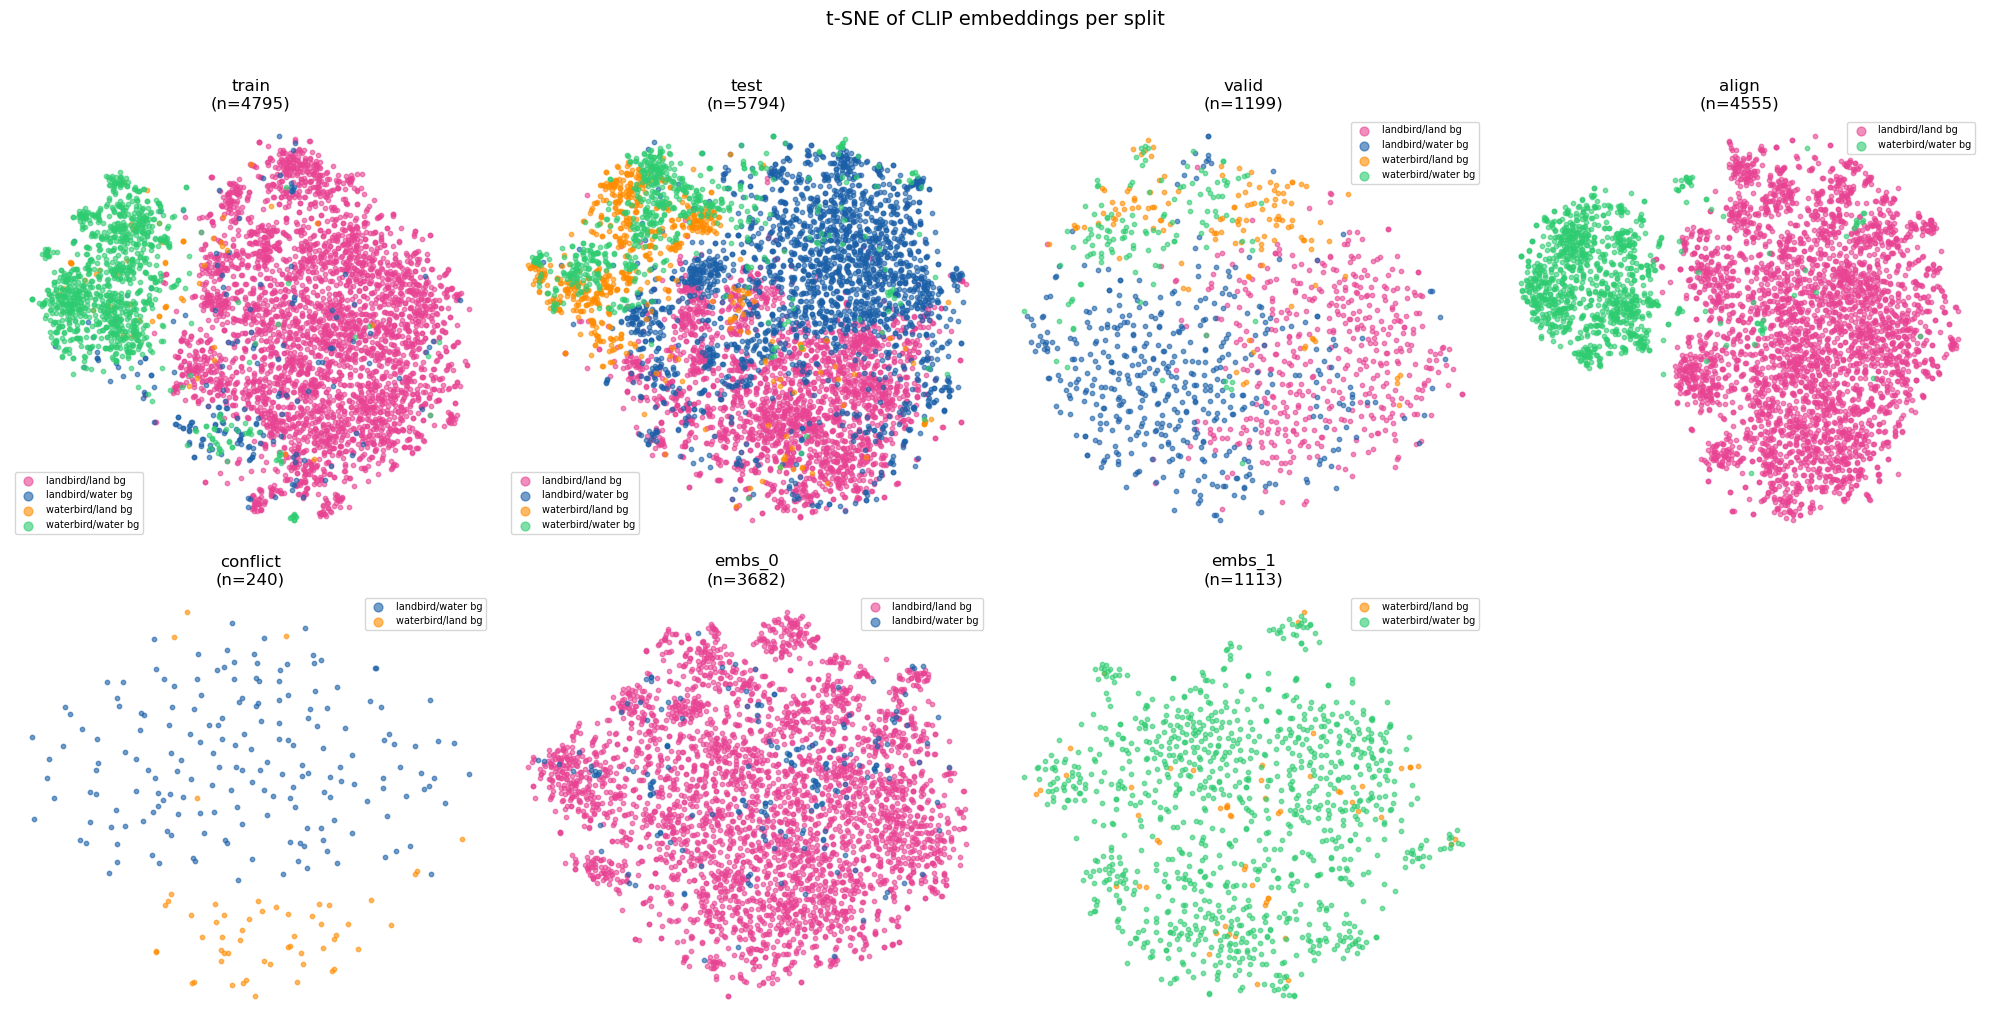

In [4]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "landbird/land bg",   1: "landbird/water bg",
               2: "waterbird/land bg",  3: "waterbird/water bg"}

colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

splits = [
    ("train",    train_embs.numpy(), train_labels, train_groups),
    ("test",     test_embs.numpy(),     test_labels,     test_groups),
    ("valid",    valid_embs.numpy(), valid_labels, valid_groups),
    ("align",    align_embs.numpy(), align_labels, align_groups),
    ("conflict", conflict_embs.numpy(), conflict_labels, conflict_groups),
    ("embs_0",    embs_0.numpy(), labels_0, groups_0),
    ("embs_1", embs_1.numpy(), labels_1, groups_1)
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()  # ← flatten to 1D

for ax, (name, embs, label, background) in zip(axes_flat, splits):
    np.random.seed(42)
    n = len(embs)
    idx = np.random.choice(len(embs), n, replace=False)
    embs_sub      = embs[idx]
    label_sub     = label[idx]
    background_sub = background[idx]
    group_sub     = label_sub * 2 + background_sub

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs_sub)

    for g, gname in group_names.items():
        mask = group_sub == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=10, alpha=0.6)

    ax.set_title(f"{name}\n(n={n})", fontsize=12)
    ax.legend(fontsize=7, markerscale=2)
    ax.axis("off")

# Hide the unused 8th subplot (7 splits, 8 axes)
axes_flat[-1].set_visible(False)

plt.suptitle("t-SNE of CLIP embeddings per split", fontsize=14, y=1.02)
plt.tight_layout()
os.makedirs("5pct/tsne", exist_ok=True)
plt.savefig("5pct/tsne/tsne_all_splits.png", dpi=150, bbox_inches="tight")
print("Saved tsne_all_splits.png")

In [5]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs("5pct/tsne", exist_ok=True)

group_names = {0: "landbird/land bg",  1: "landbird/water bg",
               2: "waterbird/land bg", 3: "waterbird/water bg"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

splits = [
    ("train",    train_embs.numpy(),    train_labels,    train_groups),
    ("test",     test_embs.numpy(),     test_labels,     test_groups),
    ("valid",    valid_embs.numpy(),    valid_labels,    valid_groups),
    ("align",    align_embs.numpy(),    align_labels,    align_groups),
    ("conflict", conflict_embs.numpy(), conflict_labels, conflict_groups),
    ("embs_0",   embs_0.numpy(),        labels_0,        groups_0),
    ("embs_1",   embs_1.numpy(),        labels_1,        groups_1)
]

for split_name, embs, label, background in splits:
    np.random.seed(42)
    n = len(embs)
    idx            = np.random.choice(n, n, replace=False)
    embs_sub       = embs[idx]
    label_sub      = label[idx]
    background_sub = background[idx]
    group_sub      = label_sub * 2 + background_sub

    print(f"Running t-SNE for {split_name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs_sub)

    plt.figure(figsize=(7, 6))
    for g, gname in group_names.items():
        mask = group_sub == g
        if mask.sum() == 0:
            continue
        plt.scatter(e2d[mask, 0], e2d[mask, 1],
                    c=colors[g], label=gname, s=15, alpha=0.7)

    plt.title(f"t-SNE — {split_name} (n={n})", fontsize=13)
    plt.legend(fontsize=9, markerscale=2)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"5pct/tsne/tsne_{split_name}.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{split_name}.png")

print("\nAll plots saved!")

Running t-SNE for train (4795 points)...
Saved tsne_train.png
Running t-SNE for test (5794 points)...
Saved tsne_test.png
Running t-SNE for valid (1199 points)...
Saved tsne_valid.png
Running t-SNE for align (4555 points)...
Saved tsne_align.png
Running t-SNE for conflict (240 points)...
Saved tsne_conflict.png
Running t-SNE for embs_0 (3682 points)...
Saved tsne_embs_0.png
Running t-SNE for embs_1 (1113 points)...
Saved tsne_embs_1.png

All plots saved!


# Debiasing Embeddings

In [6]:
# Check how spread out each group is
for g, name in group_names.items():
    mask = train_groups == g
    group = train_embs[mask]
    print(f"{name:25s}  n={mask.sum():5d}  "
          f"mean_norm={group.norm(dim=-1).mean():.3f}  "
          f"intra_sim={( (group/group.norm(dim=-1,keepdim=True)) @ (group/group.norm(dim=-1,keepdim=True)).T ).mean():.3f}")

landbird/land bg           n= 3554  mean_norm=18.053  intra_sim=0.672
landbird/water bg          n= 1241  mean_norm=18.167  intra_sim=0.642
waterbird/land bg          n=    0  mean_norm=nan  intra_sim=nan
waterbird/water bg         n=    0  mean_norm=nan  intra_sim=nan


## Similarity Threshold = 0.8

In [15]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.80
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3682, 768])
waterbird: torch.Size([1113, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3682, 1113])
mean=0.603  max=0.881  min=0.218

Pairs with sim > 0.8: 909
sim range: 0.800 - 0.881
mean sim of selected pairs: 0.814
0.00 minutes


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (landbird↔waterbird, sim>{k_threshold}): {n_pairs}")
neg_e1      = landbird_embs[landbird_idx]
neg_e2      = waterbird_embs[waterbird_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) ---
n_pos_each = n_pairs // 2

# landbird↔landbird
lb_idx1     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
lb_idx2     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
land_pos_e1 = landbird_embs[lb_idx1]
land_pos_e2 = landbird_embs[lb_idx2]

# waterbird↔waterbird
wb_idx1      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
wb_idx2      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
water_pos_e1 = waterbird_embs[wb_idx1]
water_pos_e2 = waterbird_embs[wb_idx2]

pos_e1      = torch.cat([land_pos_e1,  water_pos_e1])
pos_e2      = torch.cat([land_pos_e2,  water_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (landbird↔waterbird):                {(all_labels==0).sum()}")
print(f"  pull (landbird↔landbird + water↔water):   {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

n_wb = min(500, len(waterbird_embs) // 2)  # safe size for both slices

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(landbird_embs[:1000].to(device))
    p4 = model_head(landbird_embs[1000:2000].to(device))
    p5 = model_head(waterbird_embs[:n_wb].to(device))
    p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
print(f"Before training:")
print(f"  push_sim(landbird↔waterbird):     {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(landbird↔landbird):      {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(waterbird↔waterbird):    {F.cosine_similarity(p5,p6).mean():.3f}")
start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(landbird_embs[:1000].to(device))
            p4 = model_head(landbird_embs[1000:2000].to(device))
            p5 = model_head(waterbird_embs[:n_wb].to(device))
            p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
            push_sim       = F.cosine_similarity(p1, p2).mean().item()
            pull_landbird  = F.cosine_similarity(p3, p4).mean().item()
            pull_waterbird = F.cosine_similarity(p5, p6).mean().item()
            w_diff         = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_landbird={pull_landbird:.3f}  pull_waterbird={pull_waterbird:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "5pct/push_pull/Projection_heads/projection_head_push_pull(0.8).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (landbird↔waterbird, sim>0.8): 909

Total pairs: 1817
  push (landbird↔waterbird):                909
  pull (landbird↔landbird + water↔water):   908
Before training:
  push_sim(landbird↔waterbird):     0.814
  pull_sim(landbird↔landbird):      0.667
  pull_sim(waterbird↔waterbird):    0.645

Training...
  epoch   0  loss=0.3899  push_sim=0.826  pull_landbird=0.698  pull_waterbird=0.677  W_diff=0.00031
  epoch  10  loss=0.2826  push_sim=0.813  pull_landbird=0.784  pull_waterbird=0.782  W_diff=0.00222
  epoch  20  loss=0.1792  push_sim=0.644  pull_landbird=0.748  pull_waterbird=0.746  W_diff=0.00383
  epoch  30  loss=0.1358  push_sim=0.572  pull_landbird=0.751  pull_waterbird=0.748  W_diff=0.00470
  epoch  40  loss=0.1203  push_sim=0.548  pull_landbird=0.750  pull_waterbird=0.750  W_diff=0.00498
Done!
0.1 minutes


In [17]:
model_head.eval()
with torch.no_grad():
    landbird_proj  = model_head(landbird_embs.to(device)).cpu()
    waterbird_proj = model_head(waterbird_embs.to(device)).cpu()

    landbird_proj_norm  = landbird_proj  / landbird_proj.norm(dim=-1, keepdim=True)
    waterbird_proj_norm = waterbird_proj / waterbird_proj.norm(dim=-1, keepdim=True)
    landbird_norm       = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
    waterbird_norm      = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

    # Push: landbird↔waterbird similarity
    sim_after  = landbird_proj_norm @ waterbird_proj_norm.T
    sim_before = landbird_norm      @ waterbird_norm.T

    # Pull: within same class
    sim_ll_before = landbird_norm       @ landbird_norm.T
    sim_ll_after  = landbird_proj_norm  @ landbird_proj_norm.T
    sim_ww_before = waterbird_norm      @ waterbird_norm.T
    sim_ww_after  = waterbird_proj_norm @ waterbird_proj_norm.T

    mask_l = ~torch.eye(len(landbird_embs),  dtype=bool)
    mask_w = ~torch.eye(len(waterbird_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (landbird↔waterbird) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.8: {(sim_before_flat>0.8).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.8: {(sim_after_flat>0.8).sum()}")

print("\nPULL effect (landbird↔landbird) — want higher:")
print(f"  BEFORE: mean={sim_ll_before[mask_l].mean():.3f}  "
      f"min={sim_ll_before[mask_l].min():.3f}")
print(f"  AFTER:  mean={sim_ll_after[mask_l].mean():.3f}  "
      f"min={sim_ll_after[mask_l].min():.3f}")

print("\nPULL effect (waterbird↔waterbird) — want higher:")
print(f"  BEFORE: mean={sim_ww_before[mask_w].mean():.3f}  "
      f"min={sim_ww_before[mask_w].min():.3f}")
print(f"  AFTER:  mean={sim_ww_after[mask_w].mean():.3f}  "
      f"min={sim_ww_after[mask_w].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (landbird↔waterbird) — want lower:
  BEFORE: mean=0.603  max=0.881  >0.8: 909
  AFTER:  mean=0.385  max=0.901  >0.8: 4456

PULL effect (landbird↔landbird) — want higher:
  BEFORE: mean=0.669  min=0.220
  AFTER:  mean=0.753  min=-0.084

PULL effect (waterbird↔waterbird) — want higher:
  BEFORE: mean=0.646  min=0.299
  AFTER:  mean=0.753  min=-0.102
W_diff from identity: 0.00502


In [18]:
import os
os.makedirs("5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

torch.save(train_proj, "5pct/push_pull/embeddings/train_proj_push_pull(0.8).pt")
torch.save(valid_proj, "5pct/push_pull/embeddings/valid_proj_push_pull(0.8).pt")
torch.save(test_proj,  "5pct/push_pull/embeddings/test_proj_push_pull(0.8).pt")
print("Saved!")

Saved!


In [19]:
import os
os.makedirs("5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "5pct/push_pull/embeddings/train_proj_push_pull(0.8).pt")
torch.save(test_proj,  "5pct/push_pull/embeddings/test_proj_push_pull(0.8).pt")
torch.save(valid_proj, "5pct/push_pull/embeddings/valid_proj_push_pull(0.8).pt")
print("Saved!")

Saved!


In [20]:
train_proj=torch.load("5pct/push_pull/embeddings/train_proj_push_pull(0.8).pt")
test_proj=torch.load("5pct/push_pull/embeddings/test_proj_push_pull(0.8).pt")
valid_proj=torch.load("5pct/push_pull/embeddings/valid_proj_push_pull(0.8).pt")

/tmp/ipykernel_405339/106798900.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("5pct/push_pull/embeddings/train_proj_push_pull(0.8).pt")
/tmp/ipyk

In [21]:
print(f"train_proj: {train_proj.shape}") 
print(f"test_proj:  {test_proj.shape}")  
print(f"valid_proj: {valid_proj.shape}") 

train_proj: torch.Size([4795, 768])
test_proj:  torch.Size([5794, 768])
valid_proj: torch.Size([1199, 768])


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(train_e, val_e, train_l, val_l, val_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(val_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(val_l, preds)*100:.1f}%")

    accs = []
    for lbl, lname in [(0, "landbird"), (1, "waterbird")]:
        for bg, bname in [(0, "land bg"), (1, "water bg")]:
            mask = (val_l == lbl) & (val_g == bg)
            if mask.sum() == 0:
                continue
            acc = accuracy_score(val_l[mask], preds[mask]) * 100
            accs.append(acc)
            print(f"  {lname}/{bname}: {acc:.1f}%")

    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, valid_embs, train_labels, valid_labels, valid_groups, "BASELINE")
evaluate(train_proj, valid_proj, train_labels, valid_labels, valid_groups, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 89.7%
  landbird/land bg: 98.7%
  landbird/water bg: 83.3%
  waterbird/land bg: 73.7%
  waterbird/water bg: 96.2%
  worst: 73.7%  best: 98.7%  gap: 25.0%

  DEBIASED (linear push)
Overall accuracy: 83.3%
  landbird/land bg: 99.1%
  landbird/water bg: 66.7%
  waterbird/land bg: 72.2%
  waterbird/water bg: 97.0%
  worst: 66.7%  best: 99.1%  gap: 32.4%


## Similarity Threshold = 0.7

In [25]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.70
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3682, 768])
waterbird: torch.Size([1113, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3682, 1113])
mean=0.603  max=0.881  min=0.218

Pairs with sim > 0.7: 211865
sim range: 0.700 - 0.881
mean sim of selected pairs: 0.723
0.00 minutes


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (landbird↔waterbird, sim>{k_threshold}): {n_pairs}")
neg_e1      = landbird_embs[landbird_idx]
neg_e2      = waterbird_embs[waterbird_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) ---
n_pos_each = n_pairs // 2

# landbird↔landbird
lb_idx1     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
lb_idx2     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
land_pos_e1 = landbird_embs[lb_idx1]
land_pos_e2 = landbird_embs[lb_idx2]

# waterbird↔waterbird
wb_idx1      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
wb_idx2      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
water_pos_e1 = waterbird_embs[wb_idx1]
water_pos_e2 = waterbird_embs[wb_idx2]

pos_e1      = torch.cat([land_pos_e1,  water_pos_e1])
pos_e2      = torch.cat([land_pos_e2,  water_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (landbird↔waterbird):                {(all_labels==0).sum()}")
print(f"  pull (landbird↔landbird + water↔water):   {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

n_wb = min(500, len(waterbird_embs) // 2)  # safe size for both slices

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(landbird_embs[:1000].to(device))
    p4 = model_head(landbird_embs[1000:2000].to(device))
    p5 = model_head(waterbird_embs[:n_wb].to(device))
    p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
print(f"Before training:")
print(f"  push_sim(landbird↔waterbird):     {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(landbird↔landbird):      {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(waterbird↔waterbird):    {F.cosine_similarity(p5,p6).mean():.3f}")
start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(landbird_embs[:1000].to(device))
            p4 = model_head(landbird_embs[1000:2000].to(device))
            p5 = model_head(waterbird_embs[:n_wb].to(device))
            p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
            push_sim       = F.cosine_similarity(p1, p2).mean().item()
            pull_landbird  = F.cosine_similarity(p3, p4).mean().item()
            pull_waterbird = F.cosine_similarity(p5, p6).mean().item()
            w_diff         = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_landbird={pull_landbird:.3f}  pull_waterbird={pull_waterbird:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "5pct/push_pull/Projection_heads/projection_head_push_pull(0.7).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (landbird↔waterbird, sim>0.7): 211865

Total pairs: 423729
  push (landbird↔waterbird):                211865
  pull (landbird↔landbird + water↔water):   211864
Before training:
  push_sim(landbird↔waterbird):     0.722
  pull_sim(landbird↔landbird):      0.667
  pull_sim(waterbird↔waterbird):    0.645

Training...
  epoch   0  loss=0.0554  push_sim=0.251  pull_landbird=0.843  pull_waterbird=0.853  W_diff=0.01023
  epoch  10  loss=0.0004  push_sim=0.054  pull_landbird=0.918  pull_waterbird=0.907  W_diff=0.00845
  epoch  20  loss=0.0001  push_sim=0.006  pull_landbird=0.947  pull_waterbird=0.942  W_diff=0.00455
  epoch  30  loss=0.0001  push_sim=0.007  pull_landbird=0.956  pull_waterbird=0.941  W_diff=0.00347
  epoch  40  loss=0.0000  push_sim=0.007  pull_landbird=0.953  pull_waterbird=0.947  W_diff=0.00289
Done!
23.2 minutes


In [28]:
model_head.eval()
with torch.no_grad():
    landbird_proj  = model_head(landbird_embs.to(device)).cpu()
    waterbird_proj = model_head(waterbird_embs.to(device)).cpu()

    landbird_proj_norm  = landbird_proj  / landbird_proj.norm(dim=-1, keepdim=True)
    waterbird_proj_norm = waterbird_proj / waterbird_proj.norm(dim=-1, keepdim=True)
    landbird_norm       = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
    waterbird_norm      = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

    # Push: landbird↔waterbird similarity
    sim_after  = landbird_proj_norm @ waterbird_proj_norm.T
    sim_before = landbird_norm      @ waterbird_norm.T

    # Pull: within same class
    sim_ll_before = landbird_norm       @ landbird_norm.T
    sim_ll_after  = landbird_proj_norm  @ landbird_proj_norm.T
    sim_ww_before = waterbird_norm      @ waterbird_norm.T
    sim_ww_after  = waterbird_proj_norm @ waterbird_proj_norm.T

    mask_l = ~torch.eye(len(landbird_embs),  dtype=bool)
    mask_w = ~torch.eye(len(waterbird_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (landbird↔waterbird) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.7: {(sim_before_flat>0.7).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.7: {(sim_after_flat>0.7).sum()}")

print("\nPULL effect (landbird↔landbird) — want higher:")
print(f"  BEFORE: mean={sim_ll_before[mask_l].mean():.3f}  "
      f"min={sim_ll_before[mask_l].min():.3f}")
print(f"  AFTER:  mean={sim_ll_after[mask_l].mean():.3f}  "
      f"min={sim_ll_after[mask_l].min():.3f}")

print("\nPULL effect (waterbird↔waterbird) — want higher:")
print(f"  BEFORE: mean={sim_ww_before[mask_w].mean():.3f}  "
      f"min={sim_ww_before[mask_w].min():.3f}")
print(f"  AFTER:  mean={sim_ww_after[mask_w].mean():.3f}  "
      f"min={sim_ww_after[mask_w].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (landbird↔waterbird) — want lower:
  BEFORE: mean=0.603  max=0.881  >0.7: 211865
  AFTER:  mean=-0.065  max=0.654  >0.7: 0

PULL effect (landbird↔landbird) — want higher:
  BEFORE: mean=0.669  min=0.220
  AFTER:  mean=0.960  min=0.612

PULL effect (waterbird↔waterbird) — want higher:
  BEFORE: mean=0.646  min=0.299
  AFTER:  mean=0.946  min=0.757
W_diff from identity: 0.00269


In [29]:
import os
os.makedirs("5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "5pct/push_pull/embeddings/train_proj_push_pull(0.7).pt")
torch.save(test_proj,  "5pct/push_pull/embeddings/test_proj_push_pull(0.7).pt")
torch.save(valid_proj, "5pct/push_pull/embeddings/valid_proj_push_pull(0.7).pt")
print("Saved!")

Saved!


In [30]:
train_proj=torch.load("5pct/push_pull/embeddings/train_proj_push_pull(0.7).pt")
test_proj=torch.load("5pct/push_pull/embeddings/test_proj_push_pull(0.7).pt")
valid_proj=torch.load("5pct/push_pull/embeddings/valid_proj_push_pull(0.7).pt")

print(f"train_proj: {train_proj.shape}")  
print(f"test_proj:  {test_proj.shape}") 
print(f"valid_proj: {valid_proj.shape}")  

train_proj: torch.Size([4795, 768])
test_proj:  torch.Size([5794, 768])
valid_proj: torch.Size([1199, 768])


/tmp/ipykernel_405339/649075896.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("5pct/push_pull/embeddings/train_proj_push_pull(0.7).pt")
/tmp/ipyk

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(train_e, val_e, train_l, val_l, val_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(val_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(val_l, preds)*100:.1f}%")

    accs = []
    for lbl, lname in [(0, "landbird"), (1, "waterbird")]:
        for bg, bname in [(0, "land bg"), (1, "water bg")]:
            mask = (val_l == lbl) & (val_g == bg)
            if mask.sum() == 0:
                continue
            acc = accuracy_score(val_l[mask], preds[mask]) * 100
            accs.append(acc)
            print(f"  {lname}/{bname}: {acc:.1f}%")

    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, valid_embs, train_labels, valid_labels, valid_groups, "BASELINE")
evaluate(train_proj, valid_proj, train_labels, valid_labels, valid_groups, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 89.7%
  landbird/land bg: 98.7%
  landbird/water bg: 83.3%
  waterbird/land bg: 73.7%
  waterbird/water bg: 96.2%
  worst: 73.7%  best: 98.7%  gap: 25.0%

  DEBIASED (linear push)
Overall accuracy: 89.3%
  landbird/land bg: 98.9%
  landbird/water bg: 82.8%
  waterbird/land bg: 72.9%
  waterbird/water bg: 94.7%
  worst: 72.9%  best: 98.9%  gap: 26.0%


/tmp/ipykernel_405339/4055158214.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_head.load_state_dict(torch.load("5pct/push_pull/Projection_heads/projection_head_

Running t-SNE for train (proj) (4795 points)...
Running t-SNE for test (proj) (5794 points)...
Running t-SNE for valid (proj) (1199 points)...
Running t-SNE for align (proj) (4555 points)...
Running t-SNE for conflict (proj) (240 points)...
Running t-SNE for landbird (proj) (3682 points)...
Running t-SNE for waterbird (proj) (1113 points)...
Saved!


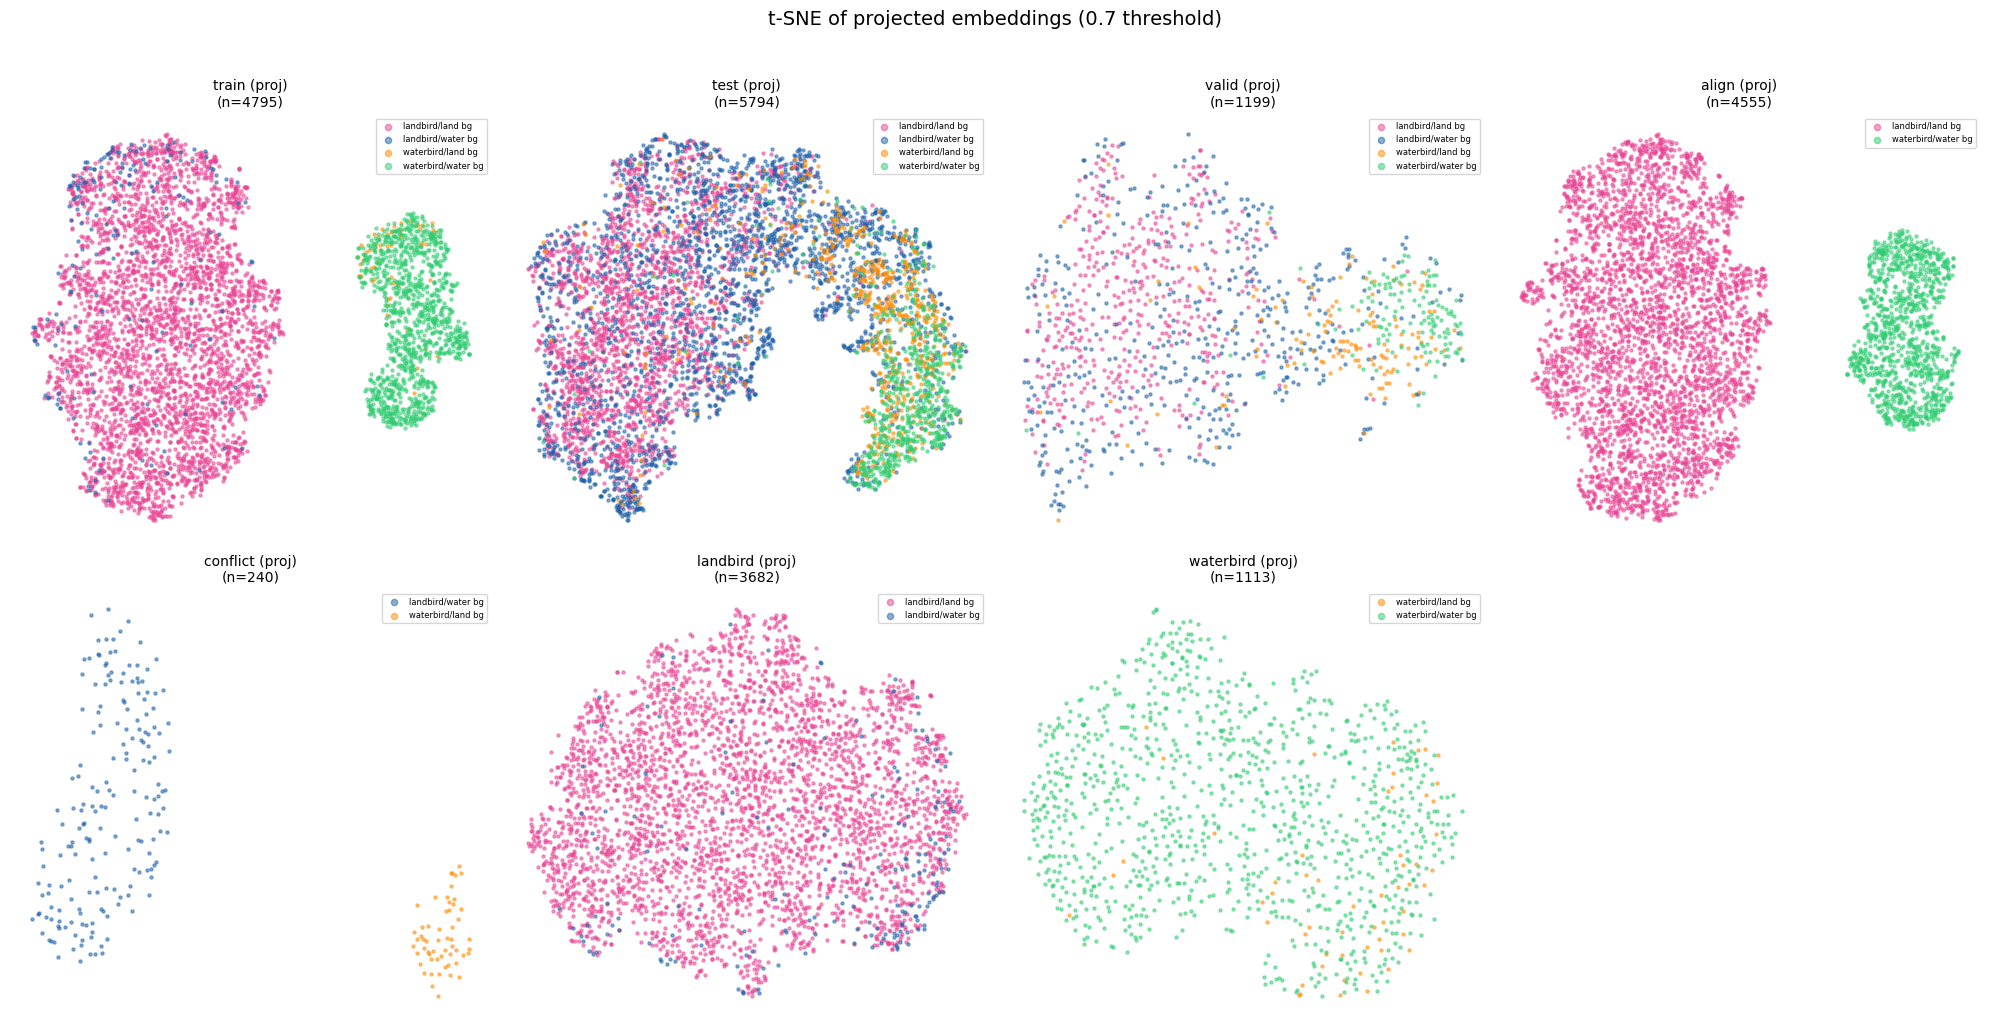

In [32]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
os.makedirs("5pct/push_pull/tsne", exist_ok=True)

group_names = {0: "landbird/land bg",  1: "landbird/water bg",
               2: "waterbird/land bg", 3: "waterbird/water bg"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

device     = "cuda"
model_head = LinearDebias().to(device)
model_head.load_state_dict(torch.load("5pct/push_pull/Projection_heads/projection_head_push_pull(0.7).pt"))
model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",     project(train_embs),    train_labels,    train_groups),
    ("test (proj)",      project(test_embs),      test_labels,     test_groups),
    ("valid (proj)",     project(valid_embs),     valid_labels,    valid_groups),
    ("align (proj)",     project(align_embs),     align_labels,    align_groups),
    ("conflict (proj)",  project(conflict_embs),  conflict_labels, conflict_groups),
    ("landbird (proj)",  project(embs_0),         labels_0,        groups_0),
    ("waterbird (proj)", project(embs_1),         labels_1,        groups_1),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for ax, (name, embs, label, background) in zip(axes_flat, splits):  # ← axes_flat
    group = label * 2 + background
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

# Hide unused 8th subplot (7 splits, 8 axes)
axes_flat[-1].set_visible(False)

plt.suptitle("t-SNE of projected embeddings (0.7 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("5pct/push_pull/tsne/tsne_projected_all_splits(0.7).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [33]:
model_head.eval()

splits = [
    ("train",     train_embs, train_labels, train_groups),
    ("test",      test_embs,  test_labels,  test_groups),
    ("valid",     valid_embs, valid_labels, valid_groups),
    ("align",     align_embs,    align_labels,    align_groups),
    ("conflict",  conflict_embs, conflict_labels, conflict_groups),
    ("landbird",  embs_0,     labels_0,     groups_0),
    ("waterbird", embs_1,     labels_1,     groups_1),
]

for name, embs_tensor, label, background in splits:
    n     = len(embs_tensor)
    group = label * 2 + background

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0:
                continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.7).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.7).png")

t-SNE original  train (4795 points)...
t-SNE projected train (4795 points)...
Saved tsne_train_orig_vs_proj(0.7).png
t-SNE original  test (5794 points)...
t-SNE projected test (5794 points)...
Saved tsne_test_orig_vs_proj(0.7).png
t-SNE original  valid (1199 points)...
t-SNE projected valid (1199 points)...
Saved tsne_valid_orig_vs_proj(0.7).png
t-SNE original  align (4555 points)...
t-SNE projected align (4555 points)...
Saved tsne_align_orig_vs_proj(0.7).png
t-SNE original  conflict (240 points)...
t-SNE projected conflict (240 points)...
Saved tsne_conflict_orig_vs_proj(0.7).png
t-SNE original  landbird (3682 points)...
t-SNE projected landbird (3682 points)...
Saved tsne_landbird_orig_vs_proj(0.7).png
t-SNE original  waterbird (1113 points)...
t-SNE projected waterbird (1113 points)...
Saved tsne_waterbird_orig_vs_proj(0.7).png


## Similarity Threshold = 0.9

In [56]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.90
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3682, 768])
waterbird: torch.Size([1113, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3682, 1113])
mean=0.603  max=0.881  min=0.218

Pairs with sim > 0.9: 0


RuntimeError: min(): Expected reduction dim to be specified for input.numel() == 0. Specify the reduction dim with the 'dim' argument.

## Similarity Threshold = 0.65

In [35]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.65
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3682, 768])
waterbird: torch.Size([1113, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3682, 1113])
mean=0.603  max=0.881  min=0.218

Pairs with sim > 0.65: 954742
sim range: 0.650 - 0.881
mean sim of selected pairs: 0.682
0.00 minutes


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (landbird↔waterbird, sim>{k_threshold}): {n_pairs}")
neg_e1      = landbird_embs[landbird_idx]
neg_e2      = waterbird_embs[waterbird_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) ---
n_pos_each = n_pairs // 2

# landbird↔landbird
lb_idx1     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
lb_idx2     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
land_pos_e1 = landbird_embs[lb_idx1]
land_pos_e2 = landbird_embs[lb_idx2]

# waterbird↔waterbird
wb_idx1      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
wb_idx2      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
water_pos_e1 = waterbird_embs[wb_idx1]
water_pos_e2 = waterbird_embs[wb_idx2]

pos_e1      = torch.cat([land_pos_e1,  water_pos_e1])
pos_e2      = torch.cat([land_pos_e2,  water_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (landbird↔waterbird):                {(all_labels==0).sum()}")
print(f"  pull (landbird↔landbird + water↔water):   {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

n_wb = min(500, len(waterbird_embs) // 2)  # safe size for both slices

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(landbird_embs[:1000].to(device))
    p4 = model_head(landbird_embs[1000:2000].to(device))
    p5 = model_head(waterbird_embs[:n_wb].to(device))
    p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
print(f"Before training:")
print(f"  push_sim(landbird↔waterbird):     {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(landbird↔landbird):      {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(waterbird↔waterbird):    {F.cosine_similarity(p5,p6).mean():.3f}")
start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(landbird_embs[:1000].to(device))
            p4 = model_head(landbird_embs[1000:2000].to(device))
            p5 = model_head(waterbird_embs[:n_wb].to(device))
            p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
            push_sim       = F.cosine_similarity(p1, p2).mean().item()
            pull_landbird  = F.cosine_similarity(p3, p4).mean().item()
            pull_waterbird = F.cosine_similarity(p5, p6).mean().item()
            w_diff         = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_landbird={pull_landbird:.3f}  pull_waterbird={pull_waterbird:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "5pct/push_pull/Projection_heads/projection_head_push_pull(0.65).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (landbird↔waterbird, sim>0.65): 954742



Total pairs: 1909484
  push (landbird↔waterbird):                954742
  pull (landbird↔landbird + water↔water):   954742
Before training:
  push_sim(landbird↔waterbird):     0.677
  pull_sim(landbird↔landbird):      0.667
  pull_sim(waterbird↔waterbird):    0.645

Training...
  epoch   0  loss=0.0185  push_sim=0.173  pull_landbird=0.889  pull_waterbird=0.888  W_diff=0.01235
  epoch  10  loss=0.0002  push_sim=-0.030  pull_landbird=0.951  pull_waterbird=0.951  W_diff=0.00304
  epoch  20  loss=0.0001  push_sim=-0.002  pull_landbird=0.950  pull_waterbird=0.943  W_diff=0.00254
  epoch  30  loss=0.0000  push_sim=-0.003  pull_landbird=0.955  pull_waterbird=0.945  W_diff=0.00218
  epoch  40  loss=0.0000  push_sim=0.021  pull_landbird=0.961  pull_waterbird=0.946  W_diff=0.00187
Done!
106.1 minutes


In [37]:
model_head.eval()
with torch.no_grad():
    landbird_proj  = model_head(landbird_embs.to(device)).cpu()
    waterbird_proj = model_head(waterbird_embs.to(device)).cpu()

    landbird_proj_norm  = landbird_proj  / landbird_proj.norm(dim=-1, keepdim=True)
    waterbird_proj_norm = waterbird_proj / waterbird_proj.norm(dim=-1, keepdim=True)
    landbird_norm       = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
    waterbird_norm      = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

    # Push: landbird↔waterbird similarity
    sim_after  = landbird_proj_norm @ waterbird_proj_norm.T
    sim_before = landbird_norm      @ waterbird_norm.T

    # Pull: within same class
    sim_ll_before = landbird_norm       @ landbird_norm.T
    sim_ll_after  = landbird_proj_norm  @ landbird_proj_norm.T
    sim_ww_before = waterbird_norm      @ waterbird_norm.T
    sim_ww_after  = waterbird_proj_norm @ waterbird_proj_norm.T

    mask_l = ~torch.eye(len(landbird_embs),  dtype=bool)
    mask_w = ~torch.eye(len(waterbird_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (landbird↔waterbird) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.65: {(sim_before_flat>0.65).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.65: {(sim_after_flat>0.65).sum()}")

print("\nPULL effect (landbird↔landbird) — want higher:")
print(f"  BEFORE: mean={sim_ll_before[mask_l].mean():.3f}  "
      f"min={sim_ll_before[mask_l].min():.3f}")
print(f"  AFTER:  mean={sim_ll_after[mask_l].mean():.3f}  "
      f"min={sim_ll_after[mask_l].min():.3f}")

print("\nPULL effect (waterbird↔waterbird) — want higher:")
print(f"  BEFORE: mean={sim_ww_before[mask_w].mean():.3f}  "
      f"min={sim_ww_before[mask_w].min():.3f}")
print(f"  AFTER:  mean={sim_ww_after[mask_w].mean():.3f}  "
      f"min={sim_ww_after[mask_w].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (landbird↔waterbird) — want lower:
  BEFORE: mean=0.603  max=0.881  >0.65: 954742
  AFTER:  mean=-0.056  max=0.627  >0.65: 0

PULL effect (landbird↔landbird) — want higher:
  BEFORE: mean=0.669  min=0.220
  AFTER:  mean=0.968  min=0.743

PULL effect (waterbird↔waterbird) — want higher:
  BEFORE: mean=0.646  min=0.299
  AFTER:  mean=0.957  min=0.794
W_diff from identity: 0.00166


In [38]:
import os
os.makedirs("5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "5pct/push_pull/embeddings/train_proj_push_pull(0.65).pt")
torch.save(test_proj,  "5pct/push_pull/embeddings/test_proj_push_pull(0.65).pt")
torch.save(valid_proj, "5pct/push_pull/embeddings/valid_proj_push_pull(0.65).pt")
print("Saved!")

Saved!


In [39]:
train_proj=torch.load("5pct/push_pull/embeddings/train_proj_push_pull(0.65).pt")
test_proj=torch.load("5pct/push_pull/embeddings/test_proj_push_pull(0.65).pt")
valid_proj=torch.load("5pct/push_pull/embeddings/valid_proj_push_pull(0.65).pt")

print(f"train_proj: {train_proj.shape}")  
print(f"test_proj:  {test_proj.shape}") 
print(f"valid_proj: {valid_proj.shape}")  

train_proj: torch.Size([4795, 768])
test_proj:  torch.Size([5794, 768])
valid_proj: torch.Size([1199, 768])


/tmp/ipykernel_405339/1421816578.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("5pct/push_pull/embeddings/train_proj_push_pull(0.65).pt")
/tmp/ip

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(train_e, val_e, train_l, val_l, val_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(val_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(val_l, preds)*100:.1f}%")

    accs = []
    for lbl, lname in [(0, "landbird"), (1, "waterbird")]:
        for bg, bname in [(0, "land bg"), (1, "water bg")]:
            mask = (val_l == lbl) & (val_g == bg)
            if mask.sum() == 0:
                continue
            acc = accuracy_score(val_l[mask], preds[mask]) * 100
            accs.append(acc)
            print(f"  {lname}/{bname}: {acc:.1f}%")

    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, valid_embs, train_labels, valid_labels, valid_groups, "BASELINE")
evaluate(train_proj, valid_proj, train_labels, valid_labels, valid_groups, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 89.7%
  landbird/land bg: 98.7%
  landbird/water bg: 83.3%
  waterbird/land bg: 73.7%
  waterbird/water bg: 96.2%
  worst: 73.7%  best: 98.7%  gap: 25.0%

  DEBIASED (linear push)
Overall accuracy: 89.5%
  landbird/land bg: 98.7%
  landbird/water bg: 83.7%
  waterbird/land bg: 72.2%
  waterbird/water bg: 94.7%
  worst: 72.2%  best: 98.7%  gap: 26.5%


Running t-SNE for train (proj) (4795 points)...


/tmp/ipykernel_405339/4092320084.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_head.load_state_dict(torch.load("5pct/push_pull/Projection_heads/projection_head_

Running t-SNE for test (proj) (5794 points)...
Running t-SNE for valid (proj) (1199 points)...
Running t-SNE for align (proj) (4555 points)...
Running t-SNE for conflict (proj) (240 points)...
Running t-SNE for landbird (proj) (3682 points)...
Running t-SNE for waterbird (proj) (1113 points)...
Saved!


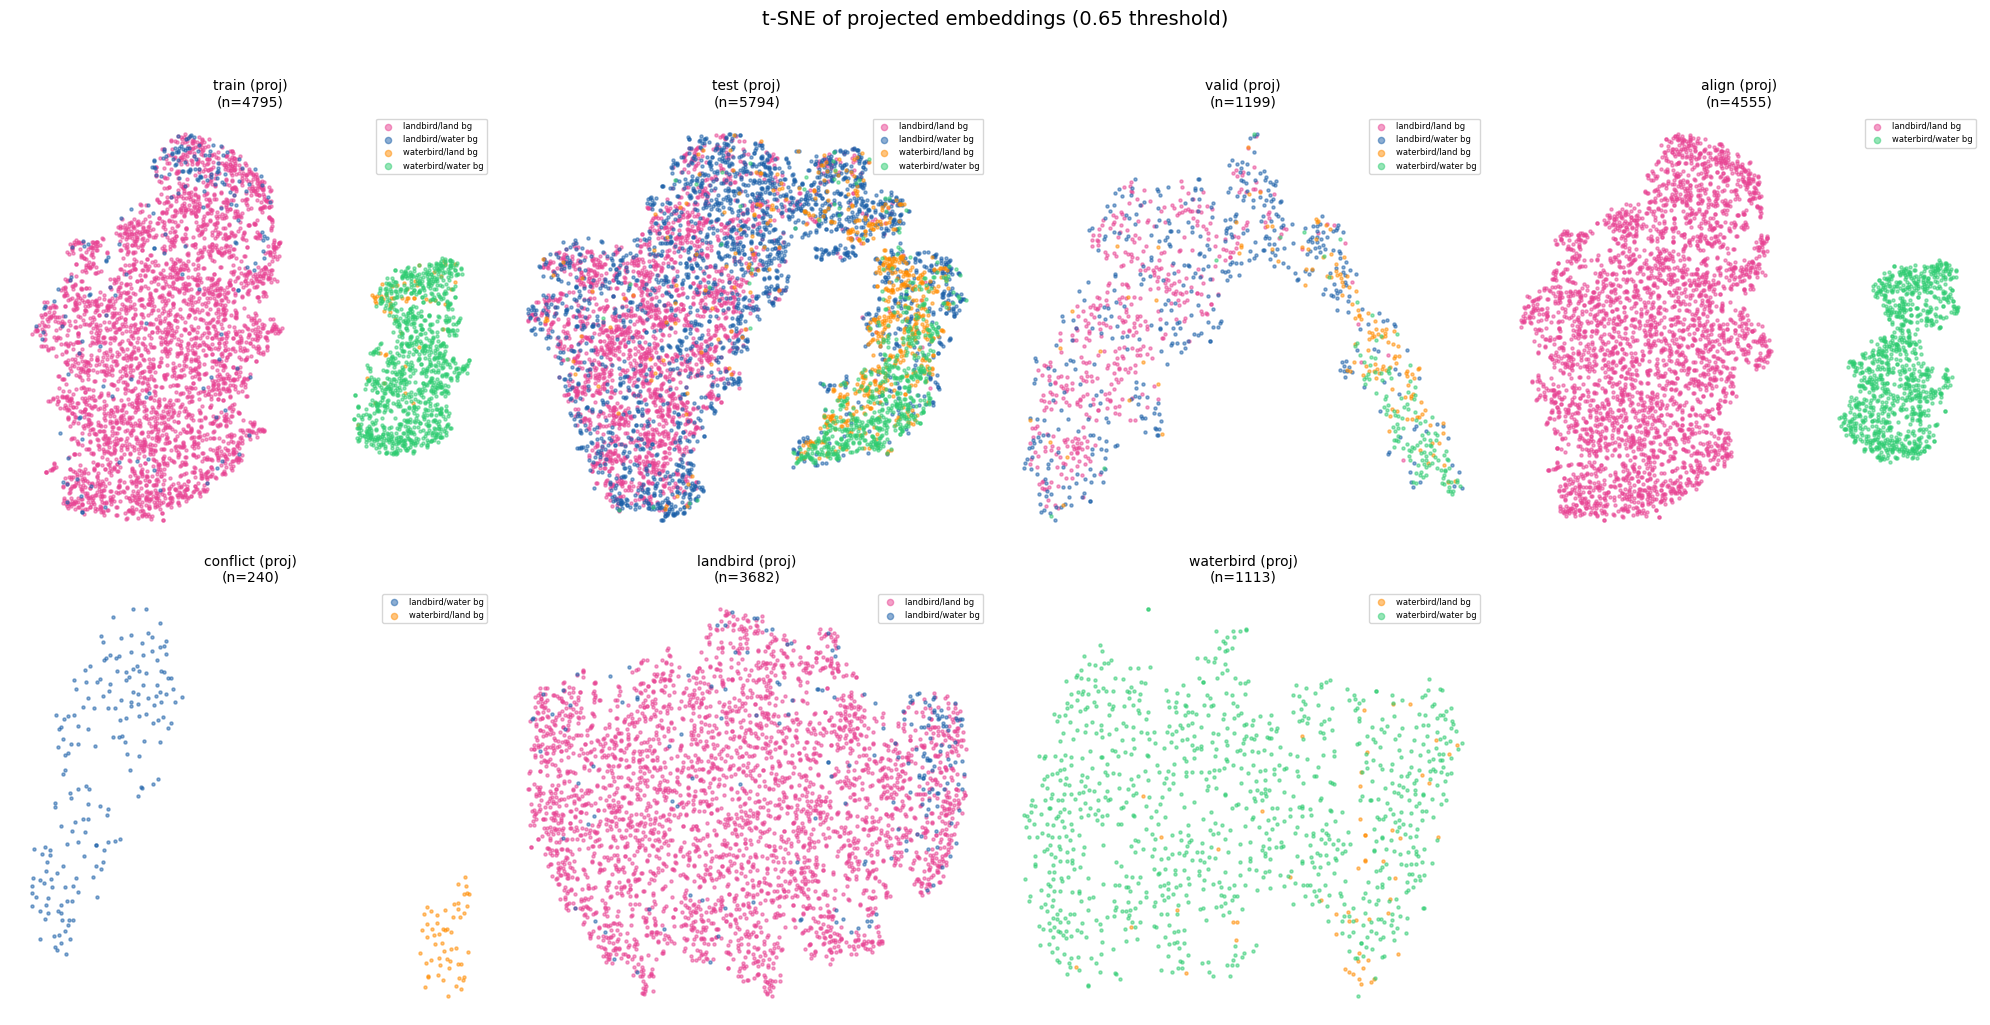

In [41]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
os.makedirs("5pct/push_pull/tsne", exist_ok=True)

group_names = {0: "landbird/land bg",  1: "landbird/water bg",
               2: "waterbird/land bg", 3: "waterbird/water bg"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

device     = "cuda"
model_head = LinearDebias().to(device)
model_head.load_state_dict(torch.load("5pct/push_pull/Projection_heads/projection_head_push_pull(0.65).pt"))
model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",     project(train_embs),    train_labels,    train_groups),
    ("test (proj)",      project(test_embs),      test_labels,     test_groups),
    ("valid (proj)",     project(valid_embs),     valid_labels,    valid_groups),
    ("align (proj)",     project(align_embs),     align_labels,    align_groups),
    ("conflict (proj)",  project(conflict_embs),  conflict_labels, conflict_groups),
    ("landbird (proj)",  project(embs_0),         labels_0,        groups_0),
    ("waterbird (proj)", project(embs_1),         labels_1,        groups_1),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for ax, (name, embs, label, background) in zip(axes_flat, splits):  # ← axes_flat
    group = label * 2 + background
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

# Hide unused 8th subplot (7 splits, 8 axes)
axes_flat[-1].set_visible(False)

plt.suptitle("t-SNE of projected embeddings (0.65 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("5pct/push_pull/tsne/tsne_projected_all_splits(0.65).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [42]:
model_head.eval()

splits = [
    ("train",     train_embs, train_labels, train_groups),
    ("test",      test_embs,  test_labels,  test_groups),
    ("valid",     valid_embs, valid_labels, valid_groups),
    ("align",     align_embs,    align_labels,    align_groups),
    ("conflict",  conflict_embs, conflict_labels, conflict_groups),
    ("landbird",  embs_0,     labels_0,     groups_0),
    ("waterbird", embs_1,     labels_1,     groups_1),
]

for name, embs_tensor, label, background in splits:
    n     = len(embs_tensor)
    group = label * 2 + background

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0:
                continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.65).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.65).png")

t-SNE original  train (4795 points)...
t-SNE projected train (4795 points)...
Saved tsne_train_orig_vs_proj(0.65).png
t-SNE original  test (5794 points)...
t-SNE projected test (5794 points)...
Saved tsne_test_orig_vs_proj(0.65).png
t-SNE original  valid (1199 points)...
t-SNE projected valid (1199 points)...
Saved tsne_valid_orig_vs_proj(0.65).png
t-SNE original  align (4555 points)...
t-SNE projected align (4555 points)...
Saved tsne_align_orig_vs_proj(0.65).png
t-SNE original  conflict (240 points)...
t-SNE projected conflict (240 points)...
Saved tsne_conflict_orig_vs_proj(0.65).png
t-SNE original  landbird (3682 points)...
t-SNE projected landbird (3682 points)...
Saved tsne_landbird_orig_vs_proj(0.65).png
t-SNE original  waterbird (1113 points)...
t-SNE projected waterbird (1113 points)...
Saved tsne_waterbird_orig_vs_proj(0.65).png


## Similarity Threshold = 0.60

In [43]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.60
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3682, 768])
waterbird: torch.Size([1113, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3682, 1113])
mean=0.603  max=0.881  min=0.218

Pairs with sim > 0.6: 2219815
sim range: 0.600 - 0.881
mean sim of selected pairs: 0.649
0.00 minutes


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (landbird↔waterbird, sim>{k_threshold}): {n_pairs}")
neg_e1      = landbird_embs[landbird_idx]
neg_e2      = waterbird_embs[waterbird_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) ---
n_pos_each = n_pairs // 2

# landbird↔landbird
lb_idx1     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
lb_idx2     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
land_pos_e1 = landbird_embs[lb_idx1]
land_pos_e2 = landbird_embs[lb_idx2]

# waterbird↔waterbird
wb_idx1      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
wb_idx2      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
water_pos_e1 = waterbird_embs[wb_idx1]
water_pos_e2 = waterbird_embs[wb_idx2]

pos_e1      = torch.cat([land_pos_e1,  water_pos_e1])
pos_e2      = torch.cat([land_pos_e2,  water_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (landbird↔waterbird):                {(all_labels==0).sum()}")
print(f"  pull (landbird↔landbird + water↔water):   {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

n_wb = min(500, len(waterbird_embs) // 2)  # safe size for both slices

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(landbird_embs[:1000].to(device))
    p4 = model_head(landbird_embs[1000:2000].to(device))
    p5 = model_head(waterbird_embs[:n_wb].to(device))
    p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
print(f"Before training:")
print(f"  push_sim(landbird↔waterbird):     {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(landbird↔landbird):      {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(waterbird↔waterbird):    {F.cosine_similarity(p5,p6).mean():.3f}")
start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(landbird_embs[:1000].to(device))
            p4 = model_head(landbird_embs[1000:2000].to(device))
            p5 = model_head(waterbird_embs[:n_wb].to(device))
            p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
            push_sim       = F.cosine_similarity(p1, p2).mean().item()
            pull_landbird  = F.cosine_similarity(p3, p4).mean().item()
            pull_waterbird = F.cosine_similarity(p5, p6).mean().item()
            w_diff         = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_landbird={pull_landbird:.3f}  pull_waterbird={pull_waterbird:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "5pct/push_pull/Projection_heads/projection_head_push_pull(0.60).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (landbird↔waterbird, sim>0.6): 2219815

Total pairs: 4439629
  push (landbird↔waterbird):                2219815
  pull (landbird↔landbird + water↔water):   2219814
Before training:
  push_sim(landbird↔waterbird):     0.634
  pull_sim(landbird↔landbird):      0.667
  pull_sim(waterbird↔waterbird):    0.645

Training...
  epoch   0  loss=0.0083  push_sim=-0.092  pull_landbird=0.920  pull_waterbird=0.901  W_diff=0.00842
  epoch  10  loss=0.0002  push_sim=-0.040  pull_landbird=0.954  pull_waterbird=0.944  W_diff=0.00263
  epoch  20  loss=0.0001  push_sim=-0.077  pull_landbird=0.954  pull_waterbird=0.938  W_diff=0.00231
  epoch  30  loss=0.0000  push_sim=-0.060  pull_landbird=0.956  pull_waterbird=0.940  W_diff=0.00202
  epoch  40  loss=0.0000  push_sim=-0.048  pull_landbird=0.959  pull_waterbird=0.944  W_diff=0.00173
Done!
112.4 minutes


In [ ]:
model_head.eval()
with torch.no_grad():
    landbird_proj  = model_head(landbird_embs.to(device)).cpu()
    waterbird_proj = model_head(waterbird_embs.to(device)).cpu()

    landbird_proj_norm  = landbird_proj  / landbird_proj.norm(dim=-1, keepdim=True)
    waterbird_proj_norm = waterbird_proj / waterbird_proj.norm(dim=-1, keepdim=True)
    landbird_norm       = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
    waterbird_norm      = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

    # Push: landbird↔waterbird similarity
    sim_after  = landbird_proj_norm @ waterbird_proj_norm.T
    sim_before = landbird_norm      @ waterbird_norm.T

    # Pull: within same class
    sim_ll_before = landbird_norm       @ landbird_norm.T
    sim_ll_after  = landbird_proj_norm  @ landbird_proj_norm.T
    sim_ww_before = waterbird_norm      @ waterbird_norm.T
    sim_ww_after  = waterbird_proj_norm @ waterbird_proj_norm.T

    mask_l = ~torch.eye(len(landbird_embs),  dtype=bool)
    mask_w = ~torch.eye(len(waterbird_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (landbird↔waterbird) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.60: {(sim_before_flat>0.60).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.60: {(sim_after_flat>0.60).sum()}")

print("\nPULL effect (landbird↔landbird) — want higher:")
print(f"  BEFORE: mean={sim_ll_before[mask_l].mean():.3f}  "
      f"min={sim_ll_before[mask_l].min():.3f}")
print(f"  AFTER:  mean={sim_ll_after[mask_l].mean():.3f}  "
      f"min={sim_ll_after[mask_l].min():.3f}")

print("\nPULL effect (waterbird↔waterbird) — want higher:")
print(f"  BEFORE: mean={sim_ww_before[mask_w].mean():.3f}  "
      f"min={sim_ww_before[mask_w].min():.3f}")
print(f"  AFTER:  mean={sim_ww_after[mask_w].mean():.3f}  "
      f"min={sim_ww_after[mask_w].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (landbird↔waterbird) — want lower:
  BEFORE: mean=0.603  max=0.881  >0.60: 2219815
  AFTER:  mean=-0.054  max=0.575  >0.60: 0

PULL effect (landbird↔landbird) — want higher:
  BEFORE: mean=0.669  min=0.220
  AFTER:  mean=0.973  min=0.799

PULL effect (waterbird↔waterbird) — want higher:
  BEFORE: mean=0.646  min=0.299
  AFTER:  mean=0.964  min=0.817
W_diff from identity: 0.00150


In [ ]:
import os
os.makedirs("5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "5pct/push_pull/embeddings/train_proj_push_pull(0.6).pt")
torch.save(test_proj,  "5pct/push_pull/embeddings/test_proj_push_pull(0.6).pt")
torch.save(valid_proj, "5pct/push_pull/embeddings/valid_proj_push_pull(0.6).pt")
print("Saved!")

Saved!


In [9]:
train_proj=torch.load("5pct/push_pull/embeddings/train_proj_push_pull(0.6).pt")
test_proj=torch.load("5pct/push_pull/embeddings/test_proj_push_pull(0.6).pt")
valid_proj=torch.load("5pct/push_pull/embeddings/valid_proj_push_pull(0.6).pt")

print(f"train_proj: {train_proj.shape}")  
print(f"test_proj:  {test_proj.shape}") 
print(f"valid_proj: {valid_proj.shape}")  

/tmp/ipykernel_567929/865045062.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("5pct/push_pull/embeddings/train_proj_push_pull(0.6).pt")
/tmp/ipyk

train_proj: torch.Size([4795, 768])
test_proj:  torch.Size([5794, 768])
valid_proj: torch.Size([1199, 768])


/tmp/ipykernel_567929/865045062.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  valid_proj=torch.load("5pct/push_pull/embeddings/valid_proj_push_pull(0.6).pt")


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(train_e, val_e, train_l, val_l, val_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(val_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(val_l, preds)*100:.1f}%")

    accs = []
    for lbl, lname in [(0, "landbird"), (1, "waterbird")]:
        for bg, bname in [(0, "land bg"), (1, "water bg")]:
            mask = (val_l == lbl) & (val_g == bg)
            if mask.sum() == 0:
                continue
            acc = accuracy_score(val_l[mask], preds[mask]) * 100
            accs.append(acc)
            print(f"  {lname}/{bname}: {acc:.1f}%")

    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, valid_embs, train_labels, valid_labels, valid_groups, "BASELINE")
evaluate(train_proj, valid_proj, train_labels, valid_labels, valid_groups, "DEBIASED (linear push)")

  BASELINE
Overall accuracy: 89.7%
  landbird/land bg: 98.7%
  landbird/water bg: 83.3%
  waterbird/land bg: 73.7%
  waterbird/water bg: 96.2%
  worst: 73.7%  best: 98.7%  gap: 25.0%

  DEBIASED (linear push)
Overall accuracy: 89.6%
  landbird/land bg: 98.7%
  landbird/water bg: 83.7%
  waterbird/land bg: 72.2%
  waterbird/water bg: 95.5%
  worst: 72.2%  best: 98.7%  gap: 26.5%


/tmp/ipykernel_567929/3124623186.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_head.load_state_dict(torch.load("5pct/push_pull/Projection_heads/projection_head_

Running t-SNE for train (proj) (4795 points)...
Running t-SNE for test (proj) (5794 points)...
Running t-SNE for valid (proj) (1199 points)...
Running t-SNE for align (proj) (4555 points)...
Running t-SNE for conflict (proj) (240 points)...
Running t-SNE for landbird (proj) (3682 points)...
Running t-SNE for waterbird (proj) (1113 points)...
Saved!


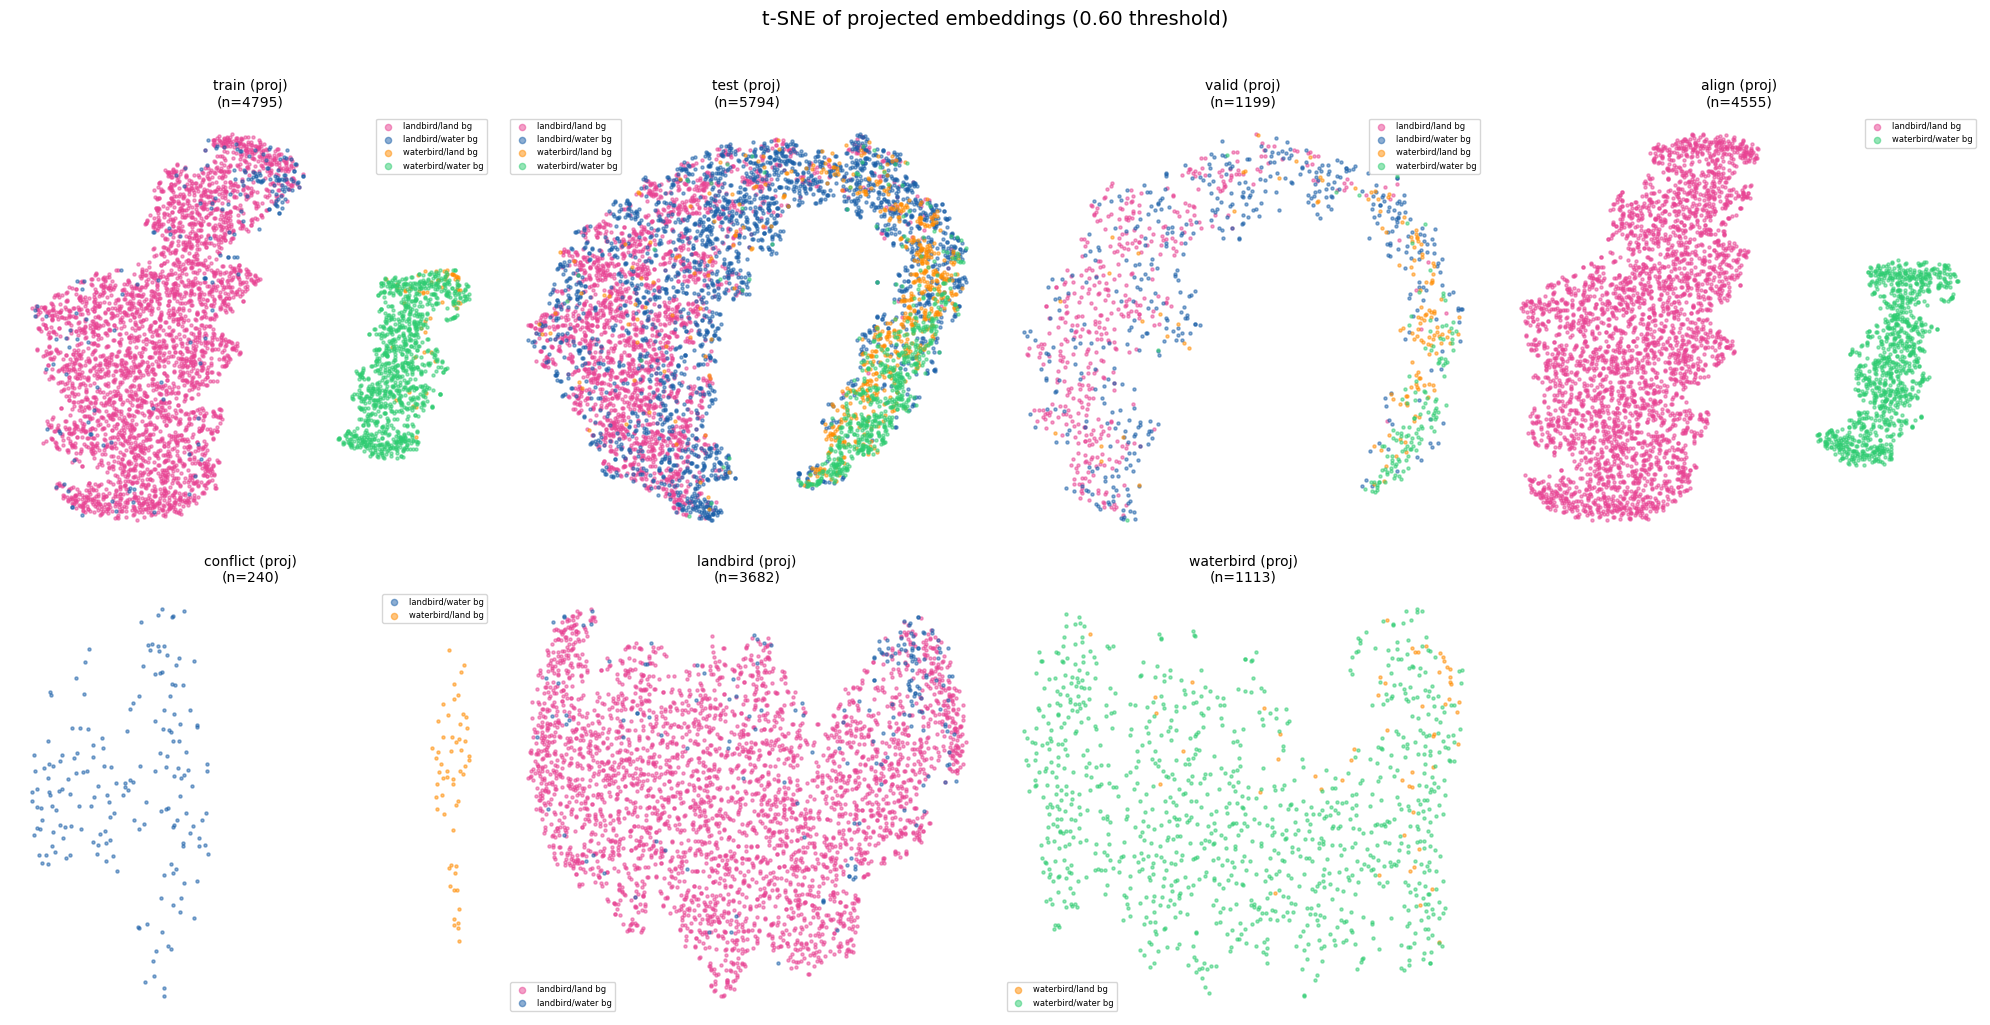

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
os.makedirs("5pct/push_pull/tsne", exist_ok=True)

group_names = {0: "landbird/land bg",  1: "landbird/water bg",
               2: "waterbird/land bg", 3: "waterbird/water bg"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

device     = "cuda"
model_head = LinearDebias().to(device)
model_head.load_state_dict(torch.load("5pct/push_pull/Projection_heads/projection_head_push_pull(0.60).pt"))
model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",     project(train_embs),    train_labels,    train_groups),
    ("test (proj)",      project(test_embs),      test_labels,     test_groups),
    ("valid (proj)",     project(valid_embs),     valid_labels,    valid_groups),
    ("align (proj)",     project(align_embs),     align_labels,    align_groups),
    ("conflict (proj)",  project(conflict_embs),  conflict_labels, conflict_groups),
    ("landbird (proj)",  project(embs_0),         labels_0,        groups_0),
    ("waterbird (proj)", project(embs_1),         labels_1,        groups_1),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for ax, (name, embs, label, background) in zip(axes_flat, splits):  # ← axes_flat
    group = label * 2 + background
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

# Hide unused 8th subplot (7 splits, 8 axes)
axes_flat[-1].set_visible(False)

plt.suptitle("t-SNE of projected embeddings (0.60 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("5pct/push_pull/tsne/tsne_projected_all_splits(0.60).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [11]:
model_head.eval()

splits = [
    ("train",     train_embs, train_labels, train_groups),
    ("test",      test_embs,  test_labels,  test_groups),
    ("valid",     valid_embs, valid_labels, valid_groups),
    ("align",     align_embs,    align_labels,    align_groups),
    ("conflict",  conflict_embs, conflict_labels, conflict_groups),
    ("landbird",  embs_0,     labels_0,     groups_0),
    ("waterbird", embs_1,     labels_1,     groups_1),
]

for name, embs_tensor, label, background in splits:
    n     = len(embs_tensor)
    group = label * 2 + background

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0:
                continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.60).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.60).png")

t-SNE original  train (4795 points)...
t-SNE projected train (4795 points)...
Saved tsne_train_orig_vs_proj(0.60).png
t-SNE original  test (5794 points)...
t-SNE projected test (5794 points)...
Saved tsne_test_orig_vs_proj(0.60).png
t-SNE original  valid (1199 points)...
t-SNE projected valid (1199 points)...
Saved tsne_valid_orig_vs_proj(0.60).png
t-SNE original  align (4555 points)...
t-SNE projected align (4555 points)...
Saved tsne_align_orig_vs_proj(0.60).png
t-SNE original  conflict (240 points)...
t-SNE projected conflict (240 points)...
Saved tsne_conflict_orig_vs_proj(0.60).png
t-SNE original  landbird (3682 points)...
t-SNE projected landbird (3682 points)...
Saved tsne_landbird_orig_vs_proj(0.60).png
t-SNE original  waterbird (1113 points)...
t-SNE projected waterbird (1113 points)...
Saved tsne_waterbird_orig_vs_proj(0.60).png


## Similarity Threshold = 0.75

In [45]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.75
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3682, 768])
waterbird: torch.Size([1113, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3682, 1113])
mean=0.603  max=0.881  min=0.218

Pairs with sim > 0.75: 21311
sim range: 0.750 - 0.881
mean sim of selected pairs: 0.767
0.00 minutes


In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (landbird↔waterbird, sim>{k_threshold}): {n_pairs}")
neg_e1      = landbird_embs[landbird_idx]
neg_e2      = waterbird_embs[waterbird_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) ---
n_pos_each = n_pairs // 2

# landbird↔landbird
lb_idx1     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
lb_idx2     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
land_pos_e1 = landbird_embs[lb_idx1]
land_pos_e2 = landbird_embs[lb_idx2]

# waterbird↔waterbird
wb_idx1      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
wb_idx2      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
water_pos_e1 = waterbird_embs[wb_idx1]
water_pos_e2 = waterbird_embs[wb_idx2]

pos_e1      = torch.cat([land_pos_e1,  water_pos_e1])
pos_e2      = torch.cat([land_pos_e2,  water_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (landbird↔waterbird):                {(all_labels==0).sum()}")
print(f"  pull (landbird↔landbird + water↔water):   {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

n_wb = min(500, len(waterbird_embs) // 2)  # safe size for both slices

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(landbird_embs[:1000].to(device))
    p4 = model_head(landbird_embs[1000:2000].to(device))
    p5 = model_head(waterbird_embs[:n_wb].to(device))
    p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
print(f"Before training:")
print(f"  push_sim(landbird↔waterbird):     {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(landbird↔landbird):      {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(waterbird↔waterbird):    {F.cosine_similarity(p5,p6).mean():.3f}")
start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(landbird_embs[:1000].to(device))
            p4 = model_head(landbird_embs[1000:2000].to(device))
            p5 = model_head(waterbird_embs[:n_wb].to(device))
            p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
            push_sim       = F.cosine_similarity(p1, p2).mean().item()
            pull_landbird  = F.cosine_similarity(p3, p4).mean().item()
            pull_waterbird = F.cosine_similarity(p5, p6).mean().item()
            w_diff         = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_landbird={pull_landbird:.3f}  pull_waterbird={pull_waterbird:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "5pct/push_pull/Projection_heads/projection_head_push_pull(0.75).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (landbird↔waterbird, sim>0.75): 21311

Total pairs: 42621
  push (landbird↔waterbird):                21311
  pull (landbird↔landbird + water↔water):   21310
Before training:
  push_sim(landbird↔waterbird):     0.767
  pull_sim(landbird↔landbird):      0.667
  pull_sim(waterbird↔waterbird):    0.645

Training...
  epoch   0  loss=0.2312  push_sim=0.541  pull_landbird=0.737  pull_waterbird=0.769  W_diff=0.00421
  epoch  10  loss=0.0203  push_sim=0.312  pull_landbird=0.852  pull_waterbird=0.852  W_diff=0.01111
  epoch  20  loss=0.0108  push_sim=0.290  pull_landbird=0.862  pull_waterbird=0.860  W_diff=0.01225
  epoch  30  loss=0.0079  push_sim=0.304  pull_landbird=0.866  pull_waterbird=0.866  W_diff=0.01248
  epoch  40  loss=0.0068  push_sim=0.295  pull_landbird=0.865  pull_waterbird=0.865  W_diff=0.01250
Done!
2.2 minutes


In [47]:
model_head.eval()
with torch.no_grad():
    landbird_proj  = model_head(landbird_embs.to(device)).cpu()
    waterbird_proj = model_head(waterbird_embs.to(device)).cpu()

    landbird_proj_norm  = landbird_proj  / landbird_proj.norm(dim=-1, keepdim=True)
    waterbird_proj_norm = waterbird_proj / waterbird_proj.norm(dim=-1, keepdim=True)
    landbird_norm       = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
    waterbird_norm      = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

    # Push: landbird↔waterbird similarity
    sim_after  = landbird_proj_norm @ waterbird_proj_norm.T
    sim_before = landbird_norm      @ waterbird_norm.T

    # Pull: within same class
    sim_ll_before = landbird_norm       @ landbird_norm.T
    sim_ll_after  = landbird_proj_norm  @ landbird_proj_norm.T
    sim_ww_before = waterbird_norm      @ waterbird_norm.T
    sim_ww_after  = waterbird_proj_norm @ waterbird_proj_norm.T

    mask_l = ~torch.eye(len(landbird_embs),  dtype=bool)
    mask_w = ~torch.eye(len(waterbird_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (landbird↔waterbird) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.75: {(sim_before_flat>0.75).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.75: {(sim_after_flat>0.75).sum()}")

print("\nPULL effect (landbird↔landbird) — want higher:")
print(f"  BEFORE: mean={sim_ll_before[mask_l].mean():.3f}  "
      f"min={sim_ll_before[mask_l].min():.3f}")
print(f"  AFTER:  mean={sim_ll_after[mask_l].mean():.3f}  "
      f"min={sim_ll_after[mask_l].min():.3f}")

print("\nPULL effect (waterbird↔waterbird) — want higher:")
print(f"  BEFORE: mean={sim_ww_before[mask_w].mean():.3f}  "
      f"min={sim_ww_before[mask_w].min():.3f}")
print(f"  AFTER:  mean={sim_ww_after[mask_w].mean():.3f}  "
      f"min={sim_ww_after[mask_w].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (landbird↔waterbird) — want lower:
  BEFORE: mean=0.603  max=0.881  >0.75: 21311
  AFTER:  mean=0.266  max=0.919  >0.75: 24014

PULL effect (landbird↔landbird) — want higher:
  BEFORE: mean=0.669  min=0.220
  AFTER:  mean=0.865  min=-0.121

PULL effect (waterbird↔waterbird) — want higher:
  BEFORE: mean=0.646  min=0.299
  AFTER:  mean=0.867  min=0.085
W_diff from identity: 0.01250


In [48]:
import os
os.makedirs("5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "5pct/push_pull/embeddings/train_proj_push_pull(0.75).pt")
torch.save(test_proj,  "5pct/push_pull/embeddings/test_proj_push_pull(0.75).pt")
torch.save(valid_proj, "5pct/push_pull/embeddings/valid_proj_push_pull(0.75).pt")
print("Saved!")

Saved!


In [49]:
train_proj=torch.load("5pct/push_pull/embeddings/train_proj_push_pull(0.75).pt")
test_proj=torch.load("5pct/push_pull/embeddings/test_proj_push_pull(0.75).pt")
valid_proj=torch.load("5pct/push_pull/embeddings/valid_proj_push_pull(0.75).pt")

print(f"train_proj: {train_proj.shape}")  
print(f"test_proj:  {test_proj.shape}") 
print(f"valid_proj: {valid_proj.shape}")  

train_proj: torch.Size([4795, 768])
test_proj:  torch.Size([5794, 768])
valid_proj: torch.Size([1199, 768])


/tmp/ipykernel_405339/115707462.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("5pct/push_pull/embeddings/train_proj_push_pull(0.75).pt")
/tmp/ipy

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(train_e, val_e, train_l, val_l, val_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(val_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(val_l, preds)*100:.1f}%")

    accs = []
    for lbl, lname in [(0, "landbird"), (1, "waterbird")]:
        for bg, bname in [(0, "land bg"), (1, "water bg")]:
            mask = (val_l == lbl) & (val_g == bg)
            if mask.sum() == 0:
                continue
            acc = accuracy_score(val_l[mask], preds[mask]) * 100
            accs.append(acc)
            print(f"  {lname}/{bname}: {acc:.1f}%")

    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, valid_embs, train_labels, valid_labels, valid_groups, "BASELINE")
evaluate(train_proj, valid_proj, train_labels, valid_labels, valid_groups, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 89.7%
  landbird/land bg: 98.7%
  landbird/water bg: 83.3%
  waterbird/land bg: 73.7%
  waterbird/water bg: 96.2%
  worst: 73.7%  best: 98.7%  gap: 25.0%

  DEBIASED (linear push)
Overall accuracy: 89.7%
  landbird/land bg: 99.1%
  landbird/water bg: 82.6%
  waterbird/land bg: 75.2%
  waterbird/water bg: 96.2%
  worst: 75.2%  best: 99.1%  gap: 24.0%


Running t-SNE for train (proj) (4795 points)...


/tmp/ipykernel_405339/3838189568.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_head.load_state_dict(torch.load("5pct/push_pull/Projection_heads/projection_head_

Running t-SNE for test (proj) (5794 points)...
Running t-SNE for valid (proj) (1199 points)...
Running t-SNE for align (proj) (4555 points)...
Running t-SNE for conflict (proj) (240 points)...
Running t-SNE for landbird (proj) (3682 points)...
Running t-SNE for waterbird (proj) (1113 points)...
Saved!


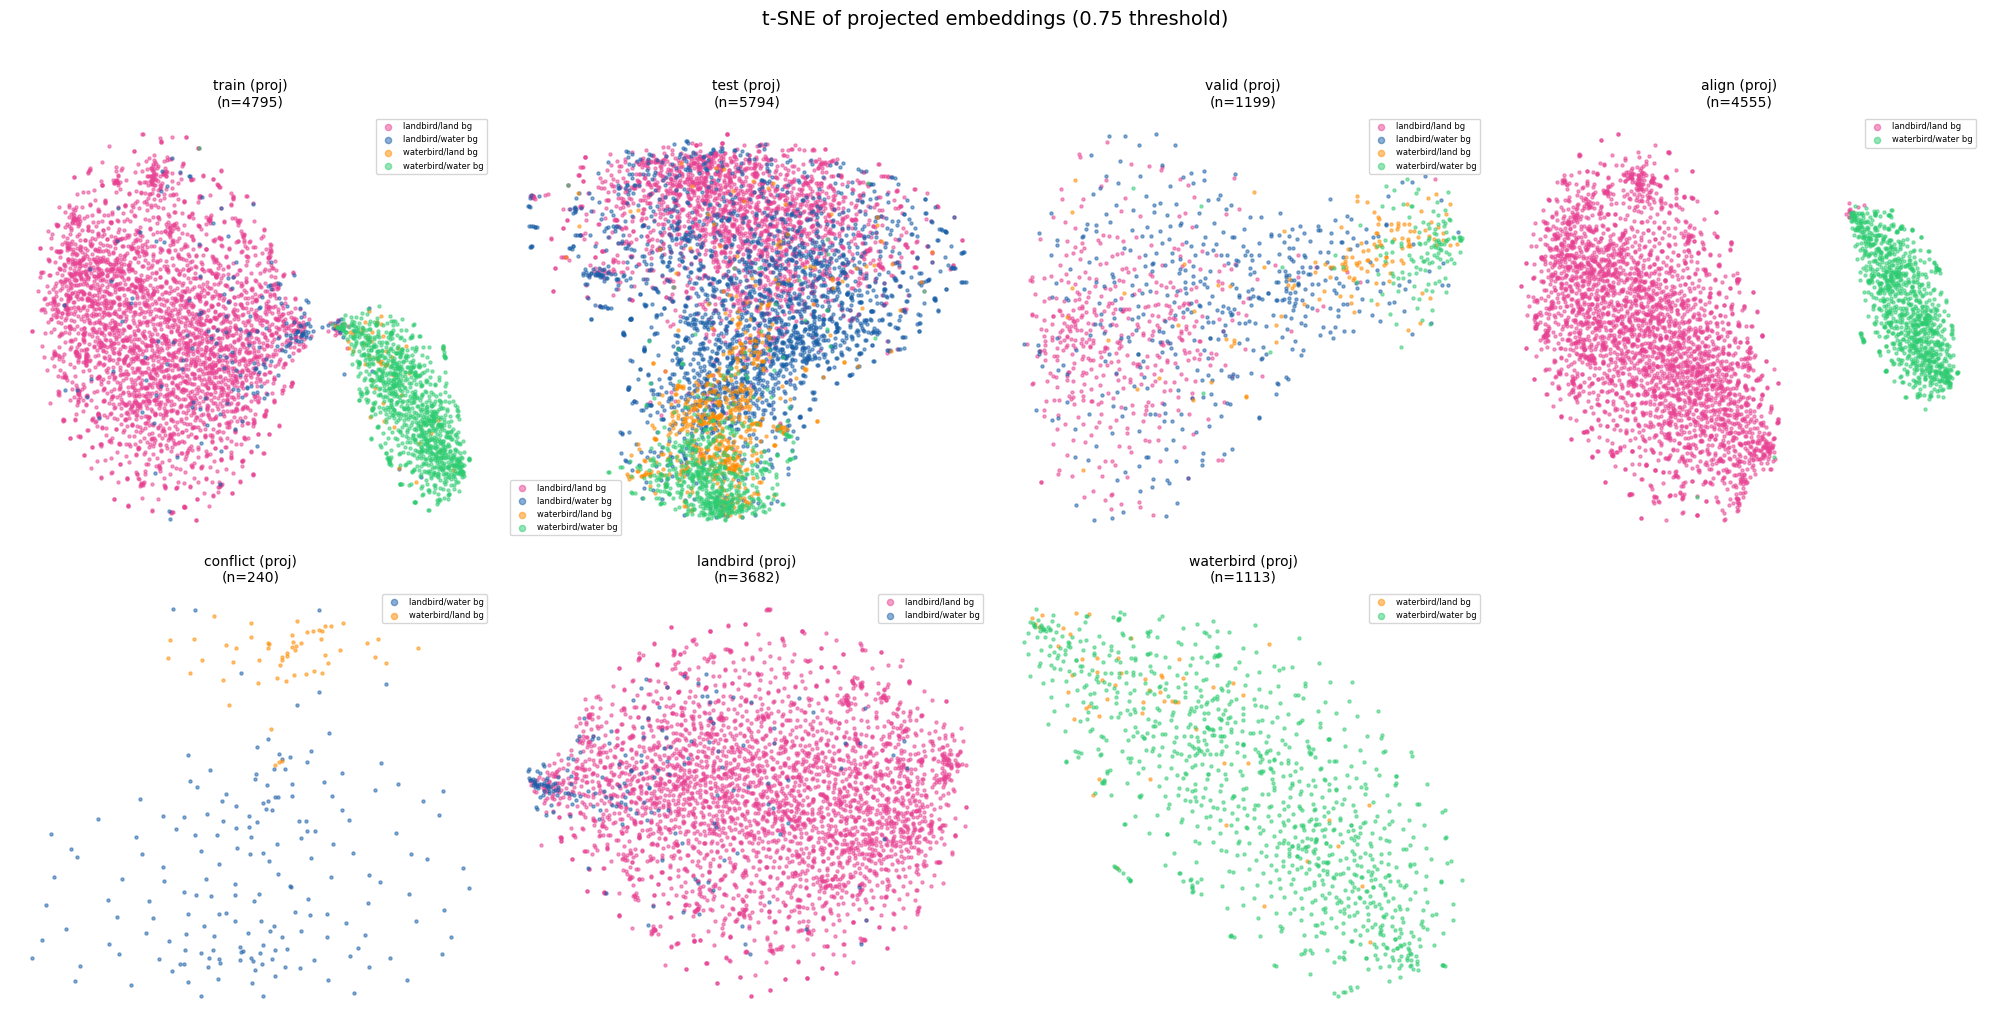

In [51]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
os.makedirs("5pct/push_pull/tsne", exist_ok=True)

group_names = {0: "landbird/land bg",  1: "landbird/water bg",
               2: "waterbird/land bg", 3: "waterbird/water bg"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

device     = "cuda"
model_head = LinearDebias().to(device)
model_head.load_state_dict(torch.load("5pct/push_pull/Projection_heads/projection_head_push_pull(0.75).pt"))
model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",     project(train_embs),    train_labels,    train_groups),
    ("test (proj)",      project(test_embs),      test_labels,     test_groups),
    ("valid (proj)",     project(valid_embs),     valid_labels,    valid_groups),
    ("align (proj)",     project(align_embs),     align_labels,    align_groups),
    ("conflict (proj)",  project(conflict_embs),  conflict_labels, conflict_groups),
    ("landbird (proj)",  project(embs_0),         labels_0,        groups_0),
    ("waterbird (proj)", project(embs_1),         labels_1,        groups_1),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for ax, (name, embs, label, background) in zip(axes_flat, splits):  # ← axes_flat
    group = label * 2 + background
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

# Hide unused 8th subplot (7 splits, 8 axes)
axes_flat[-1].set_visible(False)

plt.suptitle("t-SNE of projected embeddings (0.75 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("5pct/push_pull/tsne/tsne_projected_all_splits(0.75).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [52]:
model_head.eval()

splits = [
    ("train",     train_embs, train_labels, train_groups),
    ("test",      test_embs,  test_labels,  test_groups),
    ("valid",     valid_embs, valid_labels, valid_groups),
    ("align",     align_embs,    align_labels,    align_groups),
    ("conflict",  conflict_embs, conflict_labels, conflict_groups),
    ("landbird",  embs_0,     labels_0,     groups_0),
    ("waterbird", embs_1,     labels_1,     groups_1),
]

for name, embs_tensor, label, background in splits:
    n     = len(embs_tensor)
    group = label * 2 + background

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0:
                continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.75).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.75).png")

t-SNE original  train (4795 points)...
t-SNE projected train (4795 points)...
Saved tsne_train_orig_vs_proj(0.75).png
t-SNE original  test (5794 points)...
t-SNE projected test (5794 points)...
Saved tsne_test_orig_vs_proj(0.75).png
t-SNE original  valid (1199 points)...
t-SNE projected valid (1199 points)...
Saved tsne_valid_orig_vs_proj(0.75).png
t-SNE original  align (4555 points)...
t-SNE projected align (4555 points)...
Saved tsne_align_orig_vs_proj(0.75).png
t-SNE original  conflict (240 points)...
t-SNE projected conflict (240 points)...
Saved tsne_conflict_orig_vs_proj(0.75).png
t-SNE original  landbird (3682 points)...
t-SNE projected landbird (3682 points)...
Saved tsne_landbird_orig_vs_proj(0.75).png
t-SNE original  waterbird (1113 points)...
t-SNE projected waterbird (1113 points)...
Saved tsne_waterbird_orig_vs_proj(0.75).png


## Similarity Threshold = 0.85

In [7]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.85
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3682, 768])
waterbird: torch.Size([1113, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3682, 1113])
mean=0.603  max=0.881  min=0.218

Pairs with sim > 0.85: 20
sim range: 0.850 - 0.881
mean sim of selected pairs: 0.860
0.00 minutes


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (landbird↔waterbird, sim>{k_threshold}): {n_pairs}")
neg_e1      = landbird_embs[landbird_idx]
neg_e2      = waterbird_embs[waterbird_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) ---
n_pos_each = n_pairs // 2

# landbird↔landbird
lb_idx1     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
lb_idx2     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
land_pos_e1 = landbird_embs[lb_idx1]
land_pos_e2 = landbird_embs[lb_idx2]

# waterbird↔waterbird
wb_idx1      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
wb_idx2      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
water_pos_e1 = waterbird_embs[wb_idx1]
water_pos_e2 = waterbird_embs[wb_idx2]

pos_e1      = torch.cat([land_pos_e1,  water_pos_e1])
pos_e2      = torch.cat([land_pos_e2,  water_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (landbird↔waterbird):                {(all_labels==0).sum()}")
print(f"  pull (landbird↔landbird + water↔water):   {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

n_wb = min(500, len(waterbird_embs) // 2)  # safe size for both slices

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(landbird_embs[:1000].to(device))
    p4 = model_head(landbird_embs[1000:2000].to(device))
    p5 = model_head(waterbird_embs[:n_wb].to(device))
    p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
print(f"Before training:")
print(f"  push_sim(landbird↔waterbird):     {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(landbird↔landbird):      {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(waterbird↔waterbird):    {F.cosine_similarity(p5,p6).mean():.3f}")
start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(landbird_embs[:1000].to(device))
            p4 = model_head(landbird_embs[1000:2000].to(device))
            p5 = model_head(waterbird_embs[:n_wb].to(device))
            p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
            push_sim       = F.cosine_similarity(p1, p2).mean().item()
            pull_landbird  = F.cosine_similarity(p3, p4).mean().item()
            pull_waterbird = F.cosine_similarity(p5, p6).mean().item()
            w_diff         = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_landbird={pull_landbird:.3f}  pull_waterbird={pull_waterbird:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "5pct/push_pull/Projection_heads/projection_head_push_pull(0.85).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (landbird↔waterbird, sim>0.85): 20

Total pairs: 40
  push (landbird↔waterbird):                20
  pull (landbird↔landbird + water↔water):   20


Before training:
  push_sim(landbird↔waterbird):     0.860
  pull_sim(landbird↔landbird):      0.667
  pull_sim(waterbird↔waterbird):    0.645

Training...
  epoch   0  loss=0.4719  push_sim=0.860  pull_landbird=0.672  pull_waterbird=0.651  W_diff=0.00010
  epoch  10  loss=0.3676  push_sim=0.859  pull_landbird=0.723  pull_waterbird=0.707  W_diff=0.00101
  epoch  20  loss=0.3131  push_sim=0.846  pull_landbird=0.743  pull_waterbird=0.729  W_diff=0.00159
  epoch  30  loss=0.2862  push_sim=0.825  pull_landbird=0.739  pull_waterbird=0.725  W_diff=0.00183
  epoch  40  loss=0.2719  push_sim=0.811  pull_landbird=0.733  pull_waterbird=0.718  W_diff=0.00190
Done!
0.0 minutes


In [9]:
model_head.eval()
with torch.no_grad():
    landbird_proj  = model_head(landbird_embs.to(device)).cpu()
    waterbird_proj = model_head(waterbird_embs.to(device)).cpu()

    landbird_proj_norm  = landbird_proj  / landbird_proj.norm(dim=-1, keepdim=True)
    waterbird_proj_norm = waterbird_proj / waterbird_proj.norm(dim=-1, keepdim=True)
    landbird_norm       = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
    waterbird_norm      = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

    # Push: landbird↔waterbird similarity
    sim_after  = landbird_proj_norm @ waterbird_proj_norm.T
    sim_before = landbird_norm      @ waterbird_norm.T

    # Pull: within same class
    sim_ll_before = landbird_norm       @ landbird_norm.T
    sim_ll_after  = landbird_proj_norm  @ landbird_proj_norm.T
    sim_ww_before = waterbird_norm      @ waterbird_norm.T
    sim_ww_after  = waterbird_proj_norm @ waterbird_proj_norm.T

    mask_l = ~torch.eye(len(landbird_embs),  dtype=bool)
    mask_w = ~torch.eye(len(waterbird_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (landbird↔waterbird) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.85: {(sim_before_flat>0.85).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.85: {(sim_after_flat>0.85).sum()}")

print("\nPULL effect (landbird↔landbird) — want higher:")
print(f"  BEFORE: mean={sim_ll_before[mask_l].mean():.3f}  "
      f"min={sim_ll_before[mask_l].min():.3f}")
print(f"  AFTER:  mean={sim_ll_after[mask_l].mean():.3f}  "
      f"min={sim_ll_after[mask_l].min():.3f}")

print("\nPULL effect (waterbird↔waterbird) — want higher:")
print(f"  BEFORE: mean={sim_ww_before[mask_w].mean():.3f}  "
      f"min={sim_ww_before[mask_w].min():.3f}")
print(f"  AFTER:  mean={sim_ww_after[mask_w].mean():.3f}  "
      f"min={sim_ww_after[mask_w].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (landbird↔waterbird) — want lower:
  BEFORE: mean=0.603  max=0.881  >0.85: 20
  AFTER:  mean=0.673  max=0.881  >0.85: 177

PULL effect (landbird↔landbird) — want higher:
  BEFORE: mean=0.669  min=0.220
  AFTER:  mean=0.733  min=0.270

PULL effect (waterbird↔waterbird) — want higher:
  BEFORE: mean=0.646  min=0.299
  AFTER:  mean=0.717  min=0.394
W_diff from identity: 0.00190


In [10]:
import os
os.makedirs("5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "5pct/push_pull/embeddings/train_proj_push_pull(0.85).pt")
torch.save(test_proj,  "5pct/push_pull/embeddings/test_proj_push_pull(0.85).pt")
torch.save(valid_proj, "5pct/push_pull/embeddings/valid_proj_push_pull(0.85).pt")
print("Saved!")

Saved!


In [11]:
train_proj=torch.load("5pct/push_pull/embeddings/train_proj_push_pull(0.85).pt")
test_proj=torch.load("5pct/push_pull/embeddings/test_proj_push_pull(0.85).pt")
valid_proj=torch.load("5pct/push_pull/embeddings/valid_proj_push_pull(0.85).pt")

print(f"train_proj: {train_proj.shape}")  
print(f"test_proj:  {test_proj.shape}")  
print(f"valid_proj: {valid_proj.shape}") 

train_proj: torch.Size([4795, 768])
test_proj:  torch.Size([5794, 768])
valid_proj: torch.Size([1199, 768])


/tmp/ipykernel_405339/176899391.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("5pct/push_pull/embeddings/train_proj_push_pull(0.85).pt")
/tmp/ipy

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(train_e, val_e, train_l, val_l, val_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(val_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(val_l, preds)*100:.1f}%")

    accs = []
    for lbl, lname in [(0, "landbird"), (1, "waterbird")]:
        for bg, bname in [(0, "land bg"), (1, "water bg")]:
            mask = (val_l == lbl) & (val_g == bg)
            if mask.sum() == 0:
                continue
            acc = accuracy_score(val_l[mask], preds[mask]) * 100
            accs.append(acc)
            print(f"  {lname}/{bname}: {acc:.1f}%")

    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, valid_embs, train_labels, valid_labels, valid_groups, "BASELINE")
evaluate(train_proj, valid_proj, train_labels, valid_labels, valid_groups, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 89.7%
  landbird/land bg: 98.7%
  landbird/water bg: 83.3%
  waterbird/land bg: 73.7%
  waterbird/water bg: 96.2%
  worst: 73.7%  best: 98.7%  gap: 25.0%

  DEBIASED (linear push)
Overall accuracy: 81.7%
  landbird/land bg: 99.1%
  landbird/water bg: 63.3%
  waterbird/land bg: 67.7%
  waterbird/water bg: 98.5%
  worst: 63.3%  best: 99.1%  gap: 35.8%


In [13]:
# from sklearn.manifold import TSNE
# import matplotlib.pyplot as plt
# import numpy as np
# import torch.nn as nn
# import os
# os.makedirs("5pct/push_pull/tsne", exist_ok=True)

# group_names = {0: "landbird/land bg",  1: "landbird/water bg",
#                2: "waterbird/land bg", 3: "waterbird/water bg"}
# colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

# class LinearDebias(nn.Module):
#     def __init__(self, dim=768):
#         super().__init__()
#         self.W = nn.Parameter(torch.eye(dim))
#     def forward(self, x):
#         out = x @ self.W
#         return out / out.norm(dim=-1, keepdim=True)

# device     = "cuda"
# model_head = LinearDebias().to(device)
# model_head.load_state_dict(torch.load("5pct/push_pull/Projection_heads/projection_head_push_pull(0.85).pt"))
# model_head.eval()

# def project(embs, batch_size=512):
#     out = []
#     with torch.no_grad():
#         for i in range(0, len(embs), batch_size):
#             batch = embs[i:i+batch_size].to(device)
#             out.append(model_head(batch).cpu())
#     return torch.cat(out, dim=0).numpy()

# splits = [
#     ("train (proj)",     project(train_embs),    train_labels,    train_groups),
#     ("test (proj)",      project(test_embs),      test_labels,     test_groups),
#     ("valid (proj)",     project(valid_embs),     valid_labels,    valid_groups),
#     ("align (proj)",     project(align_embs),     align_labels,    align_groups),
#     ("conflict (proj)",  project(conflict_embs),  conflict_labels, conflict_groups),
#     ("landbird (proj)",  project(embs_0),         labels_0,        groups_0),
#     ("waterbird (proj)", project(embs_1),         labels_1,        groups_1),
# ]

# fig, axes = plt.subplots(2, 4, figsize=(20, 10))
# axes_flat = axes.flatten()

# for ax, (name, embs, label, background) in zip(axes_flat, splits):  # ← axes_flat
#     group = label * 2 + background
#     n     = len(embs)

#     print(f"Running t-SNE for {name} ({n} points)...")
#     tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
#     e2d  = tsne.fit_transform(embs)

#     for g, gname in group_names.items():
#         mask = group == g
#         if mask.sum() == 0:
#             continue
#         ax.scatter(e2d[mask, 0], e2d[mask, 1],
#                    c=colors[g], label=gname, s=5, alpha=0.5)

#     ax.set_title(f"{name}\n(n={n})", fontsize=10)
#     ax.legend(fontsize=6, markerscale=2)
#     ax.axis("off")

# # Hide unused 8th subplot (7 splits, 8 axes)
# axes_flat[-1].set_visible(False)

# plt.suptitle("t-SNE of projected embeddings (0.85 threshold)", fontsize=14, y=1.02)
# plt.tight_layout()
# plt.savefig("5pct/push_pull/tsne/tsne_projected_all_splits(0.85).png", dpi=150, bbox_inches="tight")
# print("Saved!")

In [14]:
# model_head.eval()

# splits = [
#     ("train",     train_embs, train_labels, train_groups),
#     ("test",      test_embs,  test_labels,  test_groups),
#     ("valid",     valid_embs, valid_labels, valid_groups),
#     ("align",     align_embs,    align_labels,    align_groups),
#     ("conflict",  conflict_embs, conflict_labels, conflict_groups),
#     ("landbird",  embs_0,     labels_0,     groups_0),
#     ("waterbird", embs_1,     labels_1,     groups_1),
# ]

# for name, embs_tensor, label, background in splits:
#     n     = len(embs_tensor)
#     group = label * 2 + background

#     orig = embs_tensor.cpu().numpy()
#     proj = project(embs_tensor)

#     print(f"t-SNE original  {name} ({n} points)...")
#     orig_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(orig)

#     print(f"t-SNE projected {name} ({n} points)...")
#     proj_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(proj)

#     # Side by side — left original, right projected
#     fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#     for ax, e2d, title in [
#         (axes[0], orig_2d, f"{name} — original (n={n})"),
#         (axes[1], proj_2d, f"{name} — projected (n={n})"),
#     ]:
#         for g, gname in group_names.items():
#             mask = group == g
#             if mask.sum() == 0:
#                 continue
#             ax.scatter(e2d[mask, 0], e2d[mask, 1],
#                        c=colors[g], label=gname, s=5, alpha=0.6)
#         ax.set_title(title, fontsize=12)
#         ax.axis("off")

#     # Shared legend at top
#     handles, labels = axes[0].get_legend_handles_labels()
#     fig.legend(handles, labels, loc='upper center', ncol=4,
#                bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

#     plt.tight_layout()
#     plt.savefig(f"5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.85).png", dpi=150, bbox_inches="tight")
#     plt.close()
#     print(f"Saved tsne_{name}_orig_vs_proj(0.85).png")